In [ ]:
!pip install gensim

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.7/26.7 MB 52.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 64.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.6/38.6 MB 16.4 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: scipy
    Found existing installation: scipy 1.14.1
    Uninstalling scipy-1.14.1:
      Successfully uninstalled scipy-1.14.1


In [ ]:
!pip uninstall numpy
!pip install numpy --no-cache-dir

# Reinstall the other package that uses numpy C extensions (example: pandas)
!pip install --force-reinstall --no-cache-dir pandas

Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Would remove:
    /usr/local/bin/f2py
    /usr/local/lib/python3.11/dist-packages/numpy-1.26.4.dist-info/*
    /usr/local/lib/python3.11/dist-packages/numpy.libs/libgfortran-040039e1.so.5.0.0
    /usr/local/lib/python3.11/dist-packages/numpy.libs/libopenblas64_p-r0-0cf96a72.3.23.dev.so
    /usr/local/lib/python3.11/dist-packages/numpy.libs/libquadmath-96973f99.so.0.0.0
    /usr/local/lib/python3.11/dist-packages/numpy/*
Proceed (Y/n)? Y
  Successfully uninstalled numpy-1.26.4
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.4/16.4 MB 251.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gensim 4.3.3 requires numpy<2.0,>=1.18.5, but you have numpy 2.2.4 which is incompatible.
tensorflow 2.18.0 requi

In [ ]:
# Imports: bring in libraries used below
import pandas as pd
# Imports: bring in libraries used below
import numpy as np
# Imports: bring in libraries used below
import copy
# Imports: bring in libraries used below
import re
# Imports: bring in libraries used below
import string
# Imports: bring in libraries used below
import nltk
# Imports: bring in libraries used below
from nltk.corpus import stopwords
# Imports: bring in libraries used below
from nltk.tokenize import word_tokenize
# Imports: bring in libraries used below
from nltk.stem import PorterStemmer
# Imports: bring in libraries used below
import spacy
# Imports: bring in libraries used below
import matplotlib.pyplot as plt  # For plotting coherence values
# Imports: bring in libraries used below
import seaborn as sns
# Imports: bring in libraries used below
# Using ML library
from sklearn.feature_extraction.text import CountVectorizer
# Imports: bring in libraries used below
# Using ML library
from sklearn.feature_extraction.text import TfidfVectorizer
# Imports: bring in libraries used below
from nltk.corpus import wordnet
# Imports: bring in libraries used below
from nltk.corpus import wordnet as wn
# Imports: bring in libraries used below
from google.colab import drive
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')
drive.mount('/content/drive')

# Imports: bring in libraries used below
from scipy.stats import pearsonr
# Imports: bring in libraries used below
from scipy.stats import spearmanr
# Imports: bring in libraries used below
import time
# Imports: bring in libraries used below
import kagglehub

# Imports: bring in libraries used below
import os

# Imports: bring in libraries used below
import random

# Imports: bring in libraries used below
import spacy
spacy.cli.download("en_core_web_lg")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_lg')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
# Function: clean_text — purpose inferred from its name; see inline comments.
def clean_text(text):
    delete_dict = {sp_character: '' for sp_character in string.punctuation}
    table = str.maketrans(delete_dict)
    text1 = text.translate(table)
    textArr = text1.split()
    text2 = ' '.join([w for w in textArr if not w.isdigit() and len(w) > 3])
    return text2.lower()

# Preprocessing: Cleaning the text and stopword removal
stop_words = stopwords.words('english')
en = spacy.load('en_core_web_lg')
spacy_stopwords = en.Defaults.stop_words
city_stopwords = ['pasay','muntinlupa','iloilo','davao','zamboanga','las pinas', 'paranaque', 'cagayan de oro', 'caloocan', 'iligan', 'pasig']
stop_words.extend(spacy_stopwords)
stop_words.extend(city_stopwords)

# Function: preprocess — purpose inferred from its name; see inline comments.
def preprocess(text):
    # Clean and tokenize the text
    cleaned_text = clean_text(text)
    tokens = word_tokenize(cleaned_text)

    # Initialize the stemmer
    stemmer = PorterStemmer()

    # Remove stopwords, non-alphabetic tokens, and apply stemming
    tokens = [stemmer.stem(word) for word in tokens if word.isalpha() and word not in stop_words]

    # Remove duplicate terms while preserving order
    seen = set()
    tokens = [token for token in tokens if not (token in seen or seen.add(token))]

    return tokens

In [ ]:
# Function: normalize — purpose inferred from its name; see inline comments.
def normalize(value, min_val, max_val):
    """Normalize a value between 0 and 1 using min-max normalization."""
    if max_val == min_val:
        return 0  # Avoid division by zero
    return (value - min_val) / (max_val - min_val)

# Function: compute_egovernance_index — purpose inferred from its name; see inline comments.
def compute_egovernance_index(counts_dict):
    """
    Computes the e-governance index using the formula:
    1/3 * (normalized(Count['Online Services']) + normalized(Count['Telecommunication Infrastructure']) + normalized(Count['Human Capital']))

    Parameters:
    - counts_dict (dict): A dictionary with category names as keys and count values as values

    Returns:
    - e_governance_index (float): The computed e-governance index
    """

    # Extract the count values from the dictionary
    counts = list(counts_dict.values())

    # Determine the min and max values for normalization
    min_count = min(counts)
    max_count = max(counts)

    # Normalize each count value
    normalized_counts = [normalize(count, min_count, max_count) for count in counts]

    # Calculate the e-governance index
    e_governance_index = sum(normalized_counts) / 3

    return e_governance_index

In [ ]:
# Function: filter_terms_by_tfidf — purpose inferred from its name; see inline comments.
def filter_terms_by_tfidf(preprocessed_terms, tfidf_matrix, words, threshold):
    """
    Filters tokenized terms based on their TF-IDF scores.

    Args:
        preprocessed_terms (list of list of str): Tokenized documents (list of terms).
        tfidf_matrix (scipy.sparse matrix): TF-IDF matrix from vectorizer.
        words (list of str): Feature names (words) from the vectorizer.
        threshold (float): Minimum TF-IDF score for a term to be kept.

    Returns:
        list of list of str: Filtered list of tokenized terms.
    """
    # Identify words to keep based on the threshold
    words_to_keep = set()
    for doc_index in range(tfidf_matrix.shape[0]):
        for word_index, score in zip(tfidf_matrix[doc_index].indices, tfidf_matrix[doc_index].data):
            if score >= threshold:
                words_to_keep.add(words[word_index])

    # Filter the preprocessed terms
    filtered_terms = [
        [word for word in terms if word in words_to_keep]
        for terms in preprocessed_terms
    ]

    return filtered_terms

In [ ]:
# Function: remove_duplicates_from_lists — purpose inferred from its name; see inline comments.
def remove_duplicates_from_lists(list_of_lists):
    """
    Removes duplicate terms from each list in a list of lists while preserving order.

    Args:
        list_of_lists (list of list of str): A list of tokenized terms.

    Returns:
        list of list of str: A list of lists with duplicates removed.
    """
# Function: remove_duplicates — purpose inferred from its name; see inline comments.
    def remove_duplicates(terms):
        seen = set()
        return [term for term in terms if not (term in seen or seen.add(term))]

    return [remove_duplicates(terms) for terms in list_of_lists]

In [ ]:
# Function: compute_similarity — purpose inferred from its name; see inline comments.
def compute_similarity(query_doc, corpus, model):
    # Preprocess and compute similarity scores for each document in the corpus
    similarities = {}

    # Compute the vector for the query document using the model's similarity method
    for i, doc in enumerate(corpus):
        try:
            # Calculate similarity between the query document and each document in the corpus
            sim_score = model.n_similarity(query_doc, doc)
        except KeyError:
            sim_score = 0  # In case any word in either set isn't in the model's vocabulary

        # Store similarity score for this document
        similarities[i] = sim_score
    return similarities

In [ ]:
file_path = '/content/drive/My Drive/Thesis Codes/DATA.xlsx' #ordinances
file_path1 = '/content/drive/My Drive/Thesis Codes/UN_Categories.csv' #categories

# Load data frame from file
df_data = pd.read_excel(file_path)
# Load data frame from file
df_data1 = pd.read_csv(file_path1)
#text_data = df_data['Ordinance Description'].astype(str).tolist()
text_data = df_data[['Ordinance Description', 'Full Text']].astype(str).agg(' '.join, axis=1).tolist()
cat_text_data = df_data1['Description'].astype(str).tolist()
# Load data frame from file
wordsim_df = pd.read_csv('/content/drive/My Drive/Thesis Codes/wordsim353crowd.csv')
wordsim_df.to_csv('/content/drive/My Drive/Thesis Codes/wordsim353crowd.tsv', sep='\t', index=False, header=False)

processsed_text_data = [preprocess(doc) for doc in text_data]
processed_cat_text_data = [preprocess(doc) for doc in cat_text_data]
tokens_cleaned = processsed_text_data + processed_cat_text_data

In [ ]:
# Console output for inspection
print(processsed_text_data[0])
# Console output for inspection
print(processsed_text_data[1])
# Console output for inspection
print(processsed_text_data[2])

['propos', 'amend', 'ordin', 'adopt', 'revis', 'citi', 'revenu', 'code', 'republ', 'philippin', 'sangguniang', 'panlungsod', 'seri', 'introduc', 'vice', 'mayor', 'waldetrud', 'rosario', 'sponsor', 'councilor', 'mari', 'grace', 'santo', 'cosponsor', 'counci', 'lor', 'mark', 'anthoni', 'calixto', 'marlon', 'pesebr', 'antonia', 'cuneta', 'abraham', 'albert', 'alvina', 'ricardo', 'jose', 'isidro', 'editha', 'manguerra', 'donnabel', 'vendivel', 'jennif', 'panaligan', 'king', 'magat', 'angelo', 'nicol', 'arceo', 'juli', 'gonzal', 'miguel', 'mañez', 'section', 'articl', 'constitut', 'provid', 'local', 'govern', 'unit', 'shall', 'power', 'creat', 'sourc', 'levi', 'tax', 'fee', 'charg', 'subject', 'guidelin', 'limit', 'congress', 'consist', 'basic', 'polici', 'autonomi', 'accru', 'exclus', 'known', 'provinc', 'municip', 'gener', 'deriv', 'real', 'properti', 'busi', 'receipt', 'oper', 'econom', 'enterpris', 'connect', 'exercis', 'proprietari', 'function', 'main', 'thrust', 'urban', 'growth', 'pr

Terms sorted based on TF-IDF scores of all ordinances:
           TF-IDF                 Term
0      615.035854                 rule
1      612.649185             barangay
2      596.792713                  law
3      564.754186               budget
4      560.529232              conform
...           ...                  ...
81304    0.031226  rnallocatedpnsilion
81305    0.031226                adcpt
81306    0.031226   farbanangpypnonnel
81307    0.031226               iuxviv
81308    0.031226                  irn

[81309 rows x 2 columns]


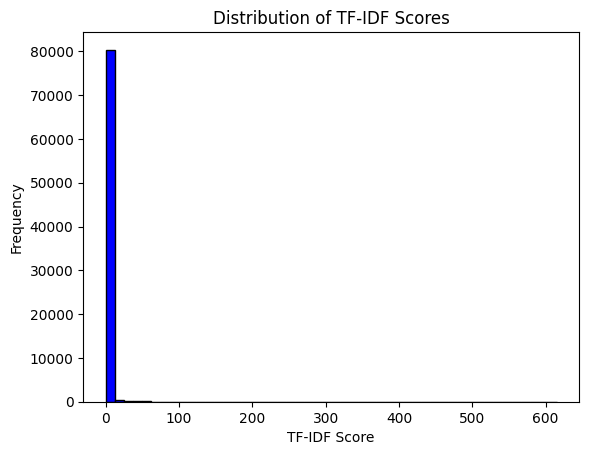

In [ ]:
processed_text_data_join = [' '.join(doc) for doc in processsed_text_data]
processed_cat_text_data_join = [' '.join(doc) for doc in processed_cat_text_data]

tfid_vectorizer = TfidfVectorizer(max_df=0.5, sublinear_tf=True)
cattfid_vectorizer = TfidfVectorizer(max_df=0.5, sublinear_tf=True)

# Model fitting / transformation step
text_data_tfidf = tfid_vectorizer.fit_transform(processed_text_data_join)
# Model fitting / transformation step
cat_text_data_tfidf = cattfid_vectorizer.fit_transform(processed_cat_text_data_join)

# Numerical computation
text_data_terms = np.array(tfid_vectorizer.get_feature_names_out())
# Numerical computation
cat_text_data_terms = np.array(cattfid_vectorizer.get_feature_names_out())

text_data_scores = text_data_tfidf.sum(axis=0).A1
cat_text_data_scores = cat_text_data_tfidf.sum(axis=0).A1

# Sort terms by their TF-IDF scores in descending order
# Numerical computation
sorted_indices = np.argsort(text_data_scores)[::-1]
sorted_terms = text_data_terms[sorted_indices]
sorted_scores = text_data_scores[sorted_indices]

sorted_terms_df = pd.DataFrame({
    'Term': sorted_terms,
    'TF-IDF': sorted_scores
})
# Console output for inspection
print("Terms sorted based on TF-IDF scores of all ordinances:")
# Console output for inspection
print(sorted_terms_df[['TF-IDF', 'Term']])

#Using histogram for determining threshold
# Plotting with matplotlib
plt.hist(text_data_scores, bins=50, color='blue', edgecolor='black')
# Plotting with matplotlib
plt.title('Distribution of TF-IDF Scores')
# Plotting with matplotlib
plt.xlabel('TF-IDF Score')
# Plotting with matplotlib
plt.ylabel('Frequency')
# Plotting with matplotlib
plt.show()


In [ ]:
preprocessed_text_data_copy = copy.deepcopy(processsed_text_data)


threshold = 0.3
filtered_terms = filter_terms_by_tfidf(preprocessed_text_data_copy, text_data_tfidf, text_data_terms, threshold)

Terms sorted based on TF-IDF scores of UN Categories:
       TF-IDF         Term
0    0.149071      certain
1    0.149071         mean
2    0.149071        capit
3    0.149071       expect
4    0.149071     everyday
..        ...          ...
354  0.062017        offic
355  0.062017       offici
356  0.062017  onestopshop
357  0.062017        onlin
358  0.062017       nation

[359 rows x 2 columns]


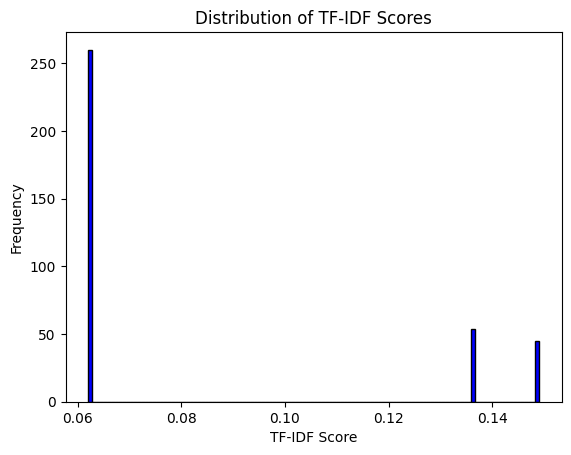

In [ ]:
# Numerical computation
cat_sorted_indices = np.argsort(cat_text_data_scores)[::-1]
cat_sorted_terms = cat_text_data_terms[cat_sorted_indices]
cat_sorted_scores = cat_text_data_scores[cat_sorted_indices]

cat_sorted_terms_df = pd.DataFrame({
    'Term': cat_sorted_terms,
    'TF-IDF': cat_sorted_scores
})
# Console output for inspection
print("Terms sorted based on TF-IDF scores of UN Categories:")
# Console output for inspection
print(cat_sorted_terms_df[['TF-IDF', 'Term']])

#Using histogram for determining threshold
# Plotting with matplotlib
plt.hist(cat_text_data_scores, bins=120, color='blue', edgecolor='black')
# Plotting with matplotlib
plt.title('Distribution of TF-IDF Scores')
# Plotting with matplotlib
plt.xlabel('TF-IDF Score')
# Plotting with matplotlib
plt.ylabel('Frequency')
# Plotting with matplotlib
plt.show()

In [ ]:
cat_preprocessed_text_data_copy = copy.deepcopy(processed_cat_text_data)


threshold = 0.05
cat_filtered_terms = filter_terms_by_tfidf(cat_preprocessed_text_data_copy, cat_text_data_tfidf, cat_text_data_terms, threshold)

type(cat_filtered_terms)

list

In [ ]:
google_model = KeyedVectors.load_word2vec_format('/content/drive/My Drive/Thesis Codes/Pretrained Models/word2vec-google-news-300.gz', binary=True)

**Pasay**

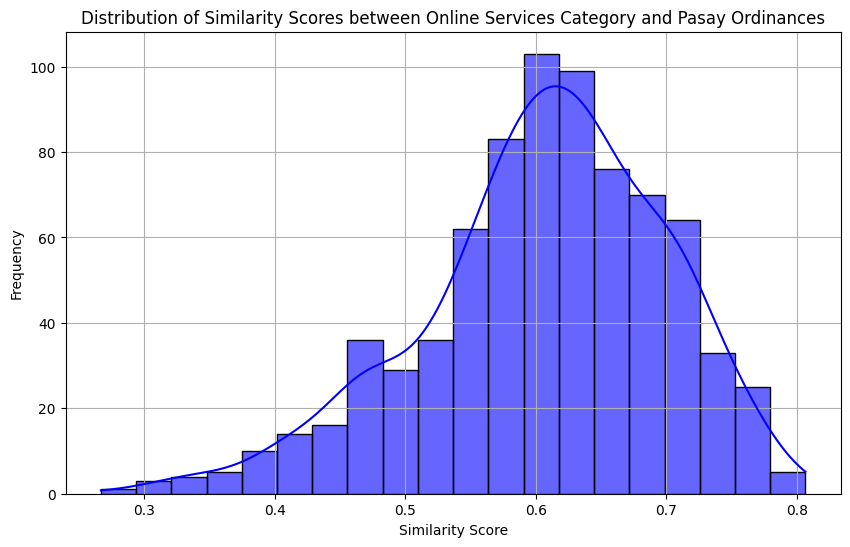

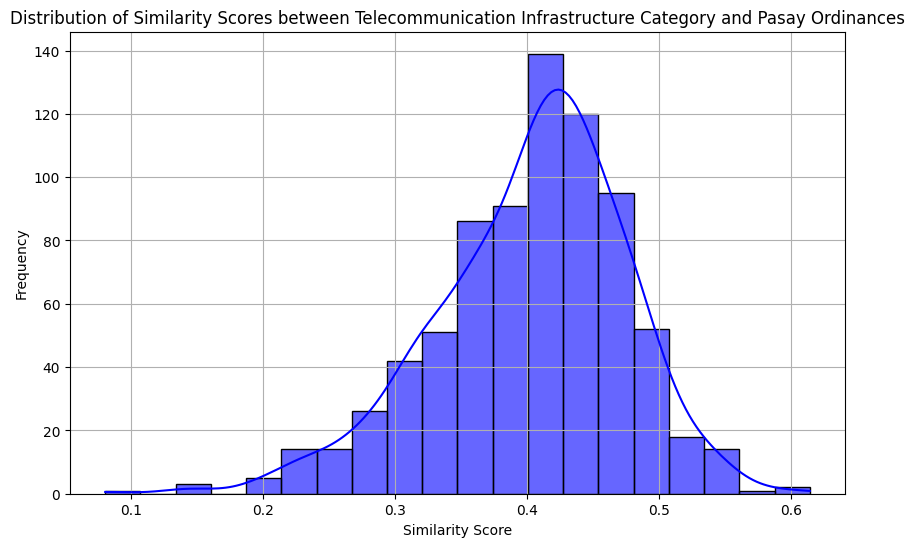

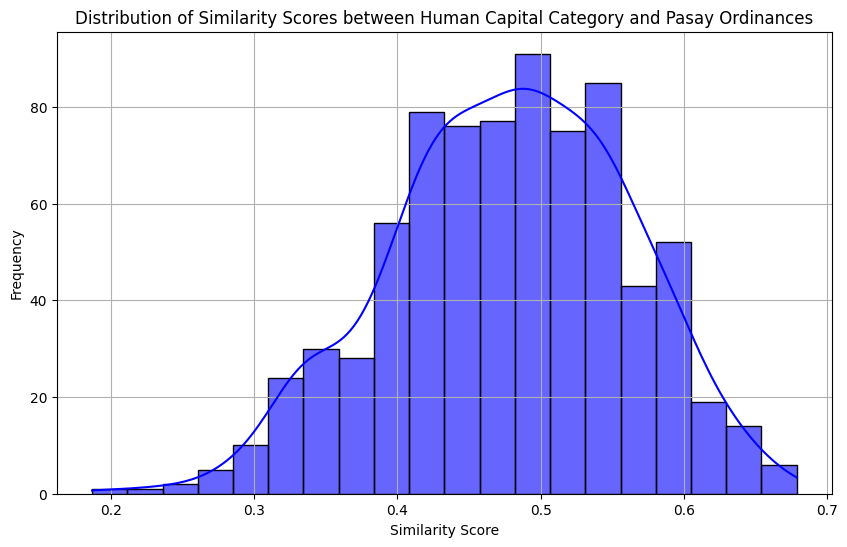

In [ ]:
preprocessed_text_data_pasay = copy.deepcopy(processsed_text_data)
threshold = 0.3
pasay_filtered_terms = filter_terms_by_tfidf(preprocessed_text_data_pasay, text_data_tfidf, text_data_terms, threshold)

#For online services:
pasay_similarities = compute_similarity(cat_filtered_terms[0], pasay_filtered_terms[0:774], google_model)

# Plotting with matplotlib
plt.figure(figsize=(10, 6))
sns.histplot(pasay_similarities, bins=20, kde=True, color='blue', edgecolor='black', alpha=0.6)
# Plotting with matplotlib
plt.title("Distribution of Similarity Scores between Online Services Category and Pasay Ordinances")
# Plotting with matplotlib
plt.xlabel("Similarity Score")
# Plotting with matplotlib
plt.ylabel("Frequency")
# Plotting with matplotlib
plt.grid(True)
# Plotting with matplotlib
plt.show()

#For telecommunication infrastractures:
pasay_similarities1 = compute_similarity(cat_filtered_terms[1], pasay_filtered_terms[0:774], google_model)
# Plotting with matplotlib
plt.figure(figsize=(10, 6))
sns.histplot(pasay_similarities1, bins=20, kde=True, color='blue', edgecolor='black', alpha=0.6)
# Plotting with matplotlib
plt.title("Distribution of Similarity Scores between Telecommunication Infrastructure Category and Pasay Ordinances")
# Plotting with matplotlib
plt.xlabel("Similarity Score")
# Plotting with matplotlib
plt.ylabel("Frequency")
# Plotting with matplotlib
plt.grid(True)
# Plotting with matplotlib
plt.show()

#For human capital:
pasay_similarities2 = compute_similarity(cat_filtered_terms[2], pasay_filtered_terms[0:774], google_model)
# Plotting with matplotlib
plt.figure(figsize=(10, 6))
sns.histplot(pasay_similarities2, bins=20, kde=True, color='blue', edgecolor='black', alpha=0.6)
# Plotting with matplotlib
plt.title("Distribution of Similarity Scores between Human Capital Category and Pasay Ordinances")
# Plotting with matplotlib
plt.xlabel("Similarity Score")
# Plotting with matplotlib
plt.ylabel("Frequency")
# Plotting with matplotlib
plt.grid(True)
# Plotting with matplotlib
plt.show()

**Iloilo**

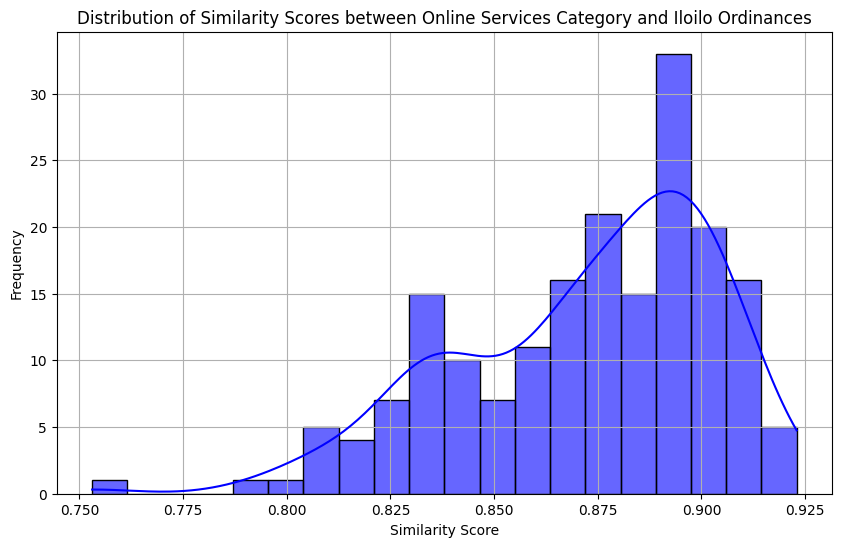

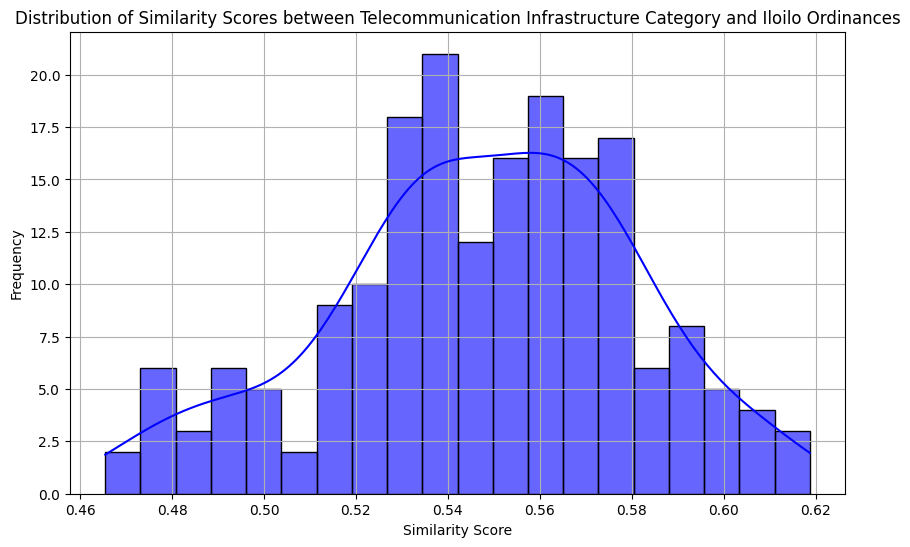

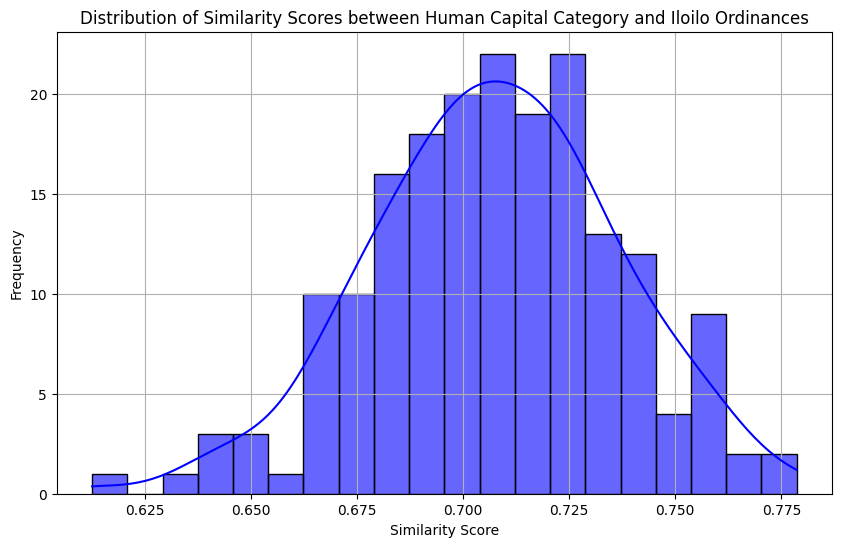

In [ ]:
# Copy of the processed text data for Iloilo
preprocessed_text_data_iloilo = copy.deepcopy(processsed_text_data)

# Filter terms based on TF-IDF threshold
iloilo_filtered_terms = filter_terms_by_tfidf(preprocessed_text_data_iloilo, text_data_tfidf, text_data_terms, threshold)

# For online services:
iloilo_similarities = compute_similarity(cat_filtered_terms[0], iloilo_filtered_terms[775:963], google_model)

# Plotting with matplotlib
plt.figure(figsize=(10, 6))
sns.histplot(iloilo_similarities, bins=20, kde=True, color='blue', edgecolor='black', alpha=0.6)
# Plotting with matplotlib
plt.title("Distribution of Similarity Scores between Online Services Category and Iloilo Ordinances")
# Plotting with matplotlib
plt.xlabel("Similarity Score")
# Plotting with matplotlib
plt.ylabel("Frequency")
# Plotting with matplotlib
plt.grid(True)
# Plotting with matplotlib
plt.show()

# For telecommunication infrastructure:
iloilo_similarities1 = compute_similarity(cat_filtered_terms[1], iloilo_filtered_terms[775:963], google_model)
# Plotting with matplotlib
plt.figure(figsize=(10, 6))
sns.histplot(iloilo_similarities1, bins=20, kde=True, color='blue', edgecolor='black', alpha=0.6)
# Plotting with matplotlib
plt.title("Distribution of Similarity Scores between Telecommunication Infrastructure Category and Iloilo Ordinances")
# Plotting with matplotlib
plt.xlabel("Similarity Score")
# Plotting with matplotlib
plt.ylabel("Frequency")
# Plotting with matplotlib
plt.grid(True)
# Plotting with matplotlib
plt.show()

# For human capital:
iloilo_similarities2 = compute_similarity(cat_filtered_terms[2], iloilo_filtered_terms[775:963], google_model)
# Plotting with matplotlib
plt.figure(figsize=(10, 6))
sns.histplot(iloilo_similarities2, bins=20, kde=True, color='blue', edgecolor='black', alpha=0.6)
# Plotting with matplotlib
plt.title("Distribution of Similarity Scores between Human Capital Category and Iloilo Ordinances")
# Plotting with matplotlib
plt.xlabel("Similarity Score")
# Plotting with matplotlib
plt.ylabel("Frequency")
# Plotting with matplotlib
plt.grid(True)
# Plotting with matplotlib
plt.show()

**Davao**

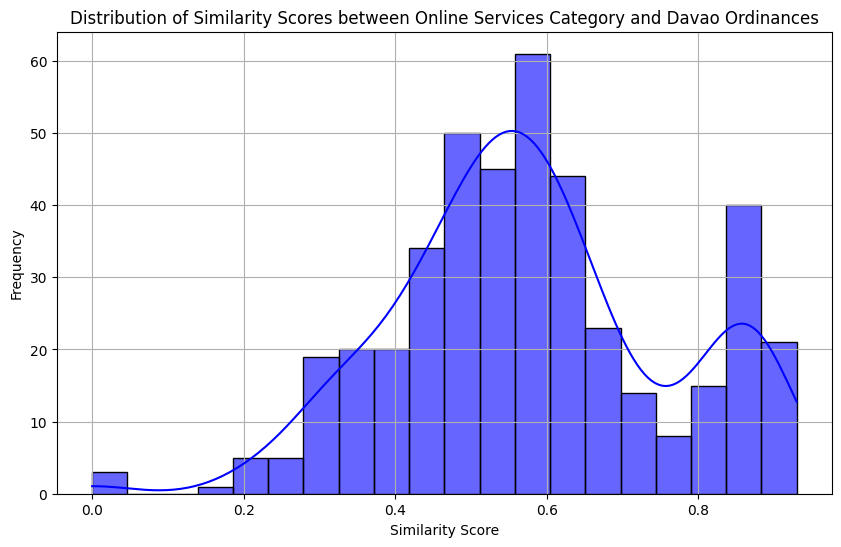

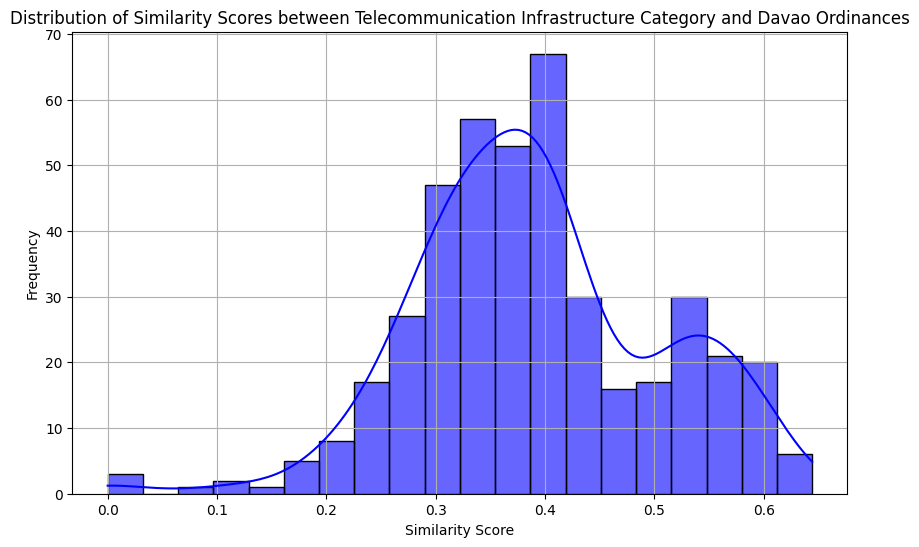

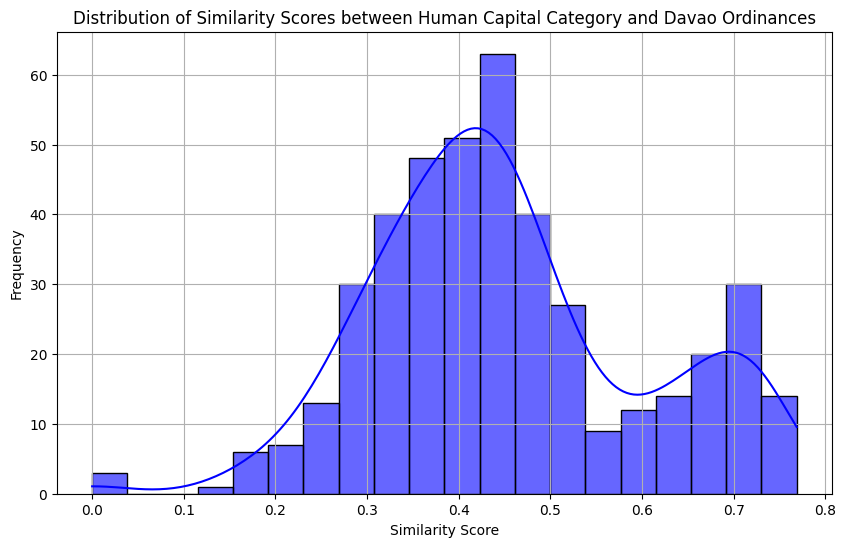

In [ ]:
# Copy of the processed text data for Davao
preprocessed_text_data_davao = copy.deepcopy(processsed_text_data)

# Filter terms based on TF-IDF threshold
davao_filtered_terms = filter_terms_by_tfidf(preprocessed_text_data_davao, text_data_tfidf, text_data_terms, threshold)
davao_filtered_terms = [sub_list for sub_list in davao_filtered_terms if sub_list]
# For online services:
davao_similarities = compute_similarity(cat_filtered_terms[0], davao_filtered_terms[964:1392], google_model)

# Plotting with matplotlib
plt.figure(figsize=(10, 6))
sns.histplot(davao_similarities, bins=20, kde=True, color='blue', edgecolor='black', alpha=0.6)
# Plotting with matplotlib
plt.title("Distribution of Similarity Scores between Online Services Category and Davao Ordinances")
# Plotting with matplotlib
plt.xlabel("Similarity Score")
# Plotting with matplotlib
plt.ylabel("Frequency")
# Plotting with matplotlib
plt.grid(True)
# Plotting with matplotlib
plt.show()

# For telecommunication infrastructure:
davao_similarities1 = compute_similarity(cat_filtered_terms[1], davao_filtered_terms[964:1392], google_model)
# Plotting with matplotlib
plt.figure(figsize=(10, 6))
sns.histplot(davao_similarities1, bins=20, kde=True, color='blue', edgecolor='black', alpha=0.6)
# Plotting with matplotlib
plt.title("Distribution of Similarity Scores between Telecommunication Infrastructure Category and Davao Ordinances")
# Plotting with matplotlib
plt.xlabel("Similarity Score")
# Plotting with matplotlib
plt.ylabel("Frequency")
# Plotting with matplotlib
plt.grid(True)
# Plotting with matplotlib
plt.show()

# For human capital:
davao_similarities2 = compute_similarity(cat_filtered_terms[2], davao_filtered_terms[964:1392], google_model)
# Plotting with matplotlib
plt.figure(figsize=(10, 6))
sns.histplot(davao_similarities2, bins=20, kde=True, color='blue', edgecolor='black', alpha=0.6)
# Plotting with matplotlib
plt.title("Distribution of Similarity Scores between Human Capital Category and Davao Ordinances")
# Plotting with matplotlib
plt.xlabel("Similarity Score")
# Plotting with matplotlib
plt.ylabel("Frequency")
# Plotting with matplotlib
plt.grid(True)
# Plotting with matplotlib
plt.show()

**Muntinlupa**

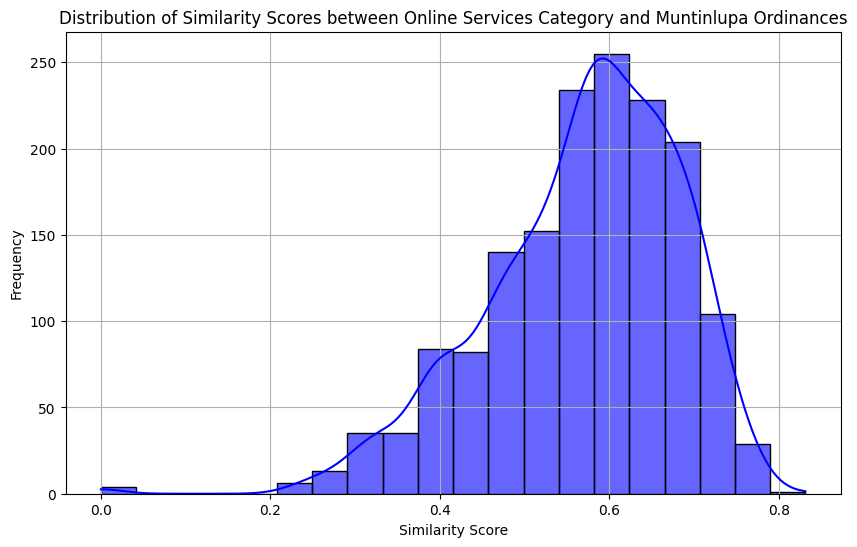

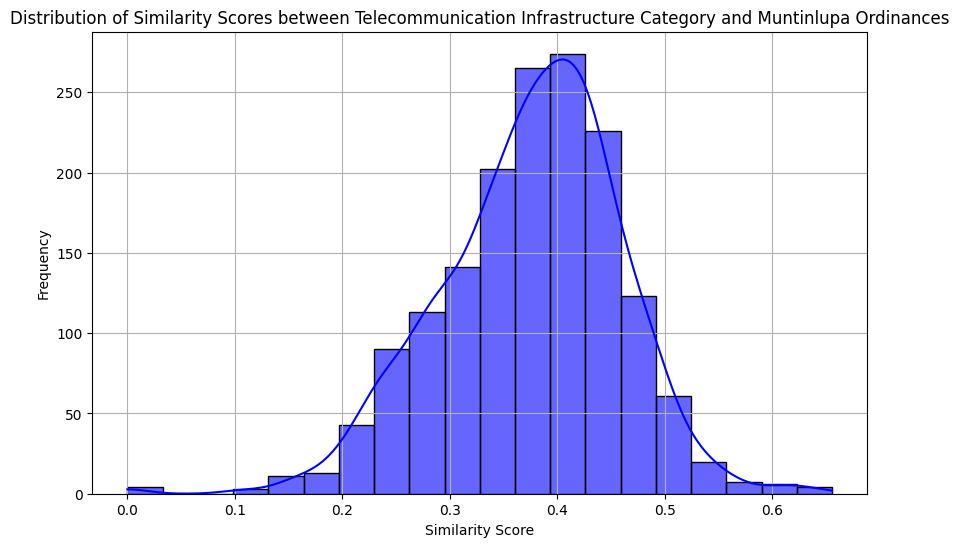

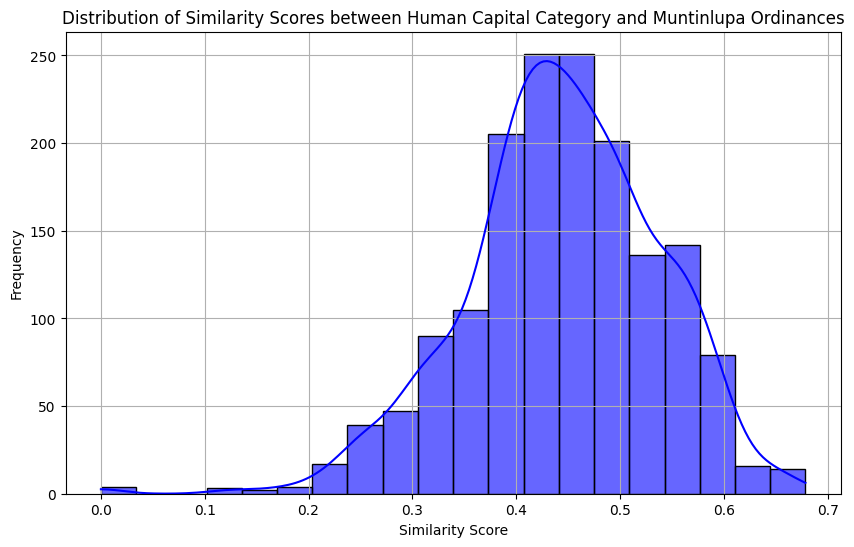

In [ ]:
# Copy of the processed text data for Muntinlupa
preprocessed_text_data_muntinlupa = copy.deepcopy(processsed_text_data)

# Filter terms based on TF-IDF threshold
muntinlupa_filtered_terms = filter_terms_by_tfidf(preprocessed_text_data_muntinlupa, text_data_tfidf, text_data_terms, threshold)
muntinlupa_filtered_terms = [sub_list for sub_list in muntinlupa_filtered_terms if sub_list]

# For online services:
muntinlupa_similarities = compute_similarity(cat_filtered_terms[0], muntinlupa_filtered_terms[1393:2999], google_model)

# Plotting with matplotlib
plt.figure(figsize=(10, 6))
sns.histplot(muntinlupa_similarities, bins=20, kde=True, color='blue', edgecolor='black', alpha=0.6)
# Plotting with matplotlib
plt.title("Distribution of Similarity Scores between Online Services Category and Muntinlupa Ordinances")
# Plotting with matplotlib
plt.xlabel("Similarity Score")
# Plotting with matplotlib
plt.ylabel("Frequency")
# Plotting with matplotlib
plt.grid(True)
# Plotting with matplotlib
plt.show()

# For telecommunication infrastructure:
muntinlupa_similarities1 = compute_similarity(cat_filtered_terms[1], muntinlupa_filtered_terms[1393:2999], google_model)
# Plotting with matplotlib
plt.figure(figsize=(10, 6))
sns.histplot(muntinlupa_similarities1, bins=20, kde=True, color='blue', edgecolor='black', alpha=0.6)
# Plotting with matplotlib
plt.title("Distribution of Similarity Scores between Telecommunication Infrastructure Category and Muntinlupa Ordinances")
# Plotting with matplotlib
plt.xlabel("Similarity Score")
# Plotting with matplotlib
plt.ylabel("Frequency")
# Plotting with matplotlib
plt.grid(True)
# Plotting with matplotlib
plt.show()

# For human capital:
muntinlupa_similarities2 = compute_similarity(cat_filtered_terms[2], muntinlupa_filtered_terms[1393:2999], google_model)
# Plotting with matplotlib
plt.figure(figsize=(10, 6))
sns.histplot(muntinlupa_similarities2, bins=20, kde=True, color='blue', edgecolor='black', alpha=0.6)
# Plotting with matplotlib
plt.title("Distribution of Similarity Scores between Human Capital Category and Muntinlupa Ordinances")
# Plotting with matplotlib
plt.xlabel("Similarity Score")
# Plotting with matplotlib
plt.ylabel("Frequency")
# Plotting with matplotlib
plt.grid(True)
# Plotting with matplotlib
plt.show()

**Zamboanga**

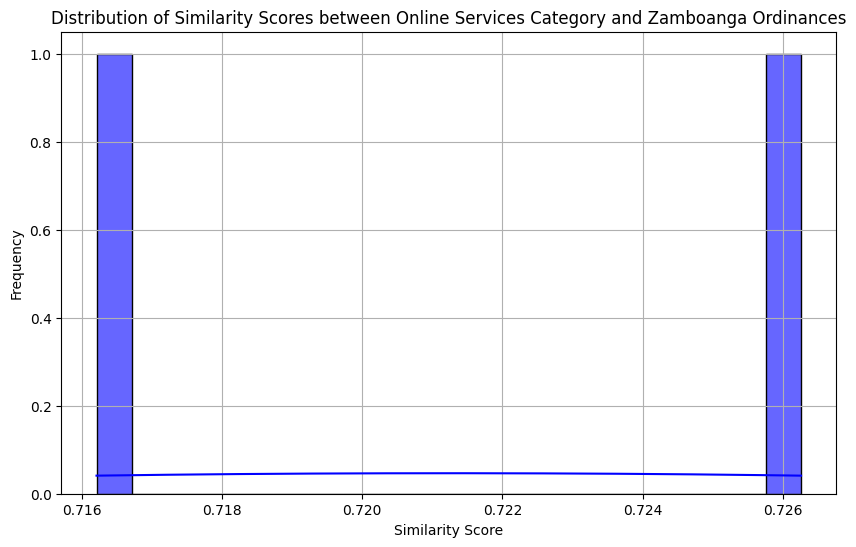

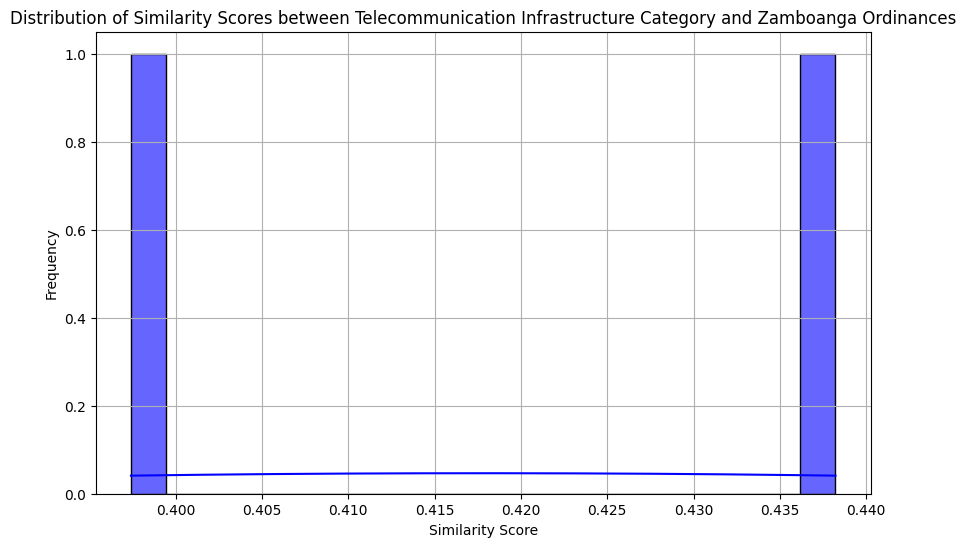

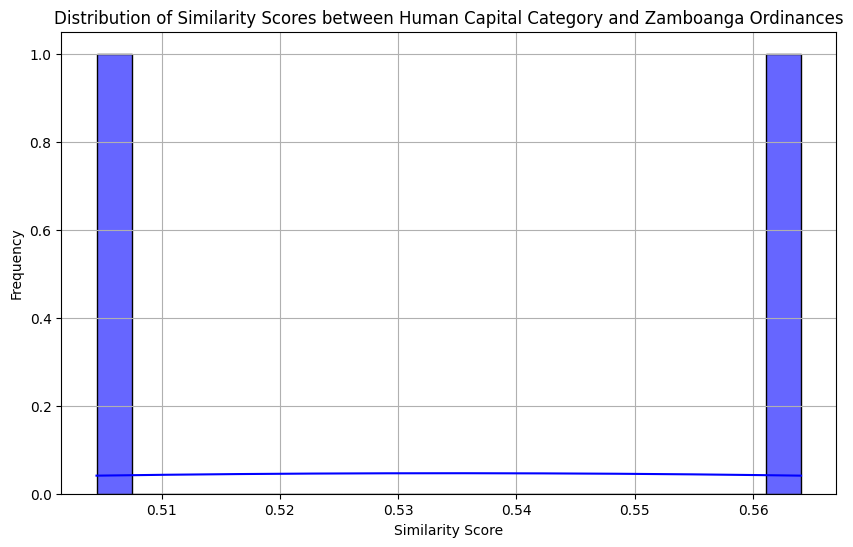

In [ ]:
# Copy of the processed text data for Zamboanga
preprocessed_text_data_zamboanga = copy.deepcopy(processsed_text_data)

# Filter terms based on TF-IDF threshold
zamboanga_filtered_terms = filter_terms_by_tfidf(preprocessed_text_data_zamboanga, text_data_tfidf, text_data_terms, threshold)
zamboanga_filtered_terms = [sub_list for sub_list in zamboanga_filtered_terms if sub_list]

# For online services:
zamboanga_similarities = compute_similarity(cat_filtered_terms[0], zamboanga_filtered_terms[3000:3002], google_model)

# Plotting with matplotlib
plt.figure(figsize=(10, 6))
sns.histplot(zamboanga_similarities, bins=20, kde=True, color='blue', edgecolor='black', alpha=0.6)
# Plotting with matplotlib
plt.title("Distribution of Similarity Scores between Online Services Category and Zamboanga Ordinances")
# Plotting with matplotlib
plt.xlabel("Similarity Score")
# Plotting with matplotlib
plt.ylabel("Frequency")
# Plotting with matplotlib
plt.grid(True)
# Plotting with matplotlib
plt.show()

# For telecommunication infrastructure:
zamboanga_similarities1 = compute_similarity(cat_filtered_terms[1], zamboanga_filtered_terms[3000:3002], google_model)
# Plotting with matplotlib
plt.figure(figsize=(10, 6))
sns.histplot(zamboanga_similarities1, bins=20, kde=True, color='blue', edgecolor='black', alpha=0.6)
# Plotting with matplotlib
plt.title("Distribution of Similarity Scores between Telecommunication Infrastructure Category and Zamboanga Ordinances")
# Plotting with matplotlib
plt.xlabel("Similarity Score")
# Plotting with matplotlib
plt.ylabel("Frequency")
# Plotting with matplotlib
plt.grid(True)
# Plotting with matplotlib
plt.show()

# For human capital:
zamboanga_similarities2 = compute_similarity(cat_filtered_terms[2], zamboanga_filtered_terms[3000:3002], google_model)
# Plotting with matplotlib
plt.figure(figsize=(10, 6))
sns.histplot(zamboanga_similarities2, bins=20, kde=True, color='blue', edgecolor='black', alpha=0.6)
# Plotting with matplotlib
plt.title("Distribution of Similarity Scores between Human Capital Category and Zamboanga Ordinances")
# Plotting with matplotlib
plt.xlabel("Similarity Score")
# Plotting with matplotlib
plt.ylabel("Frequency")
# Plotting with matplotlib
plt.grid(True)
# Plotting with matplotlib
plt.show()

**Las Pinas**

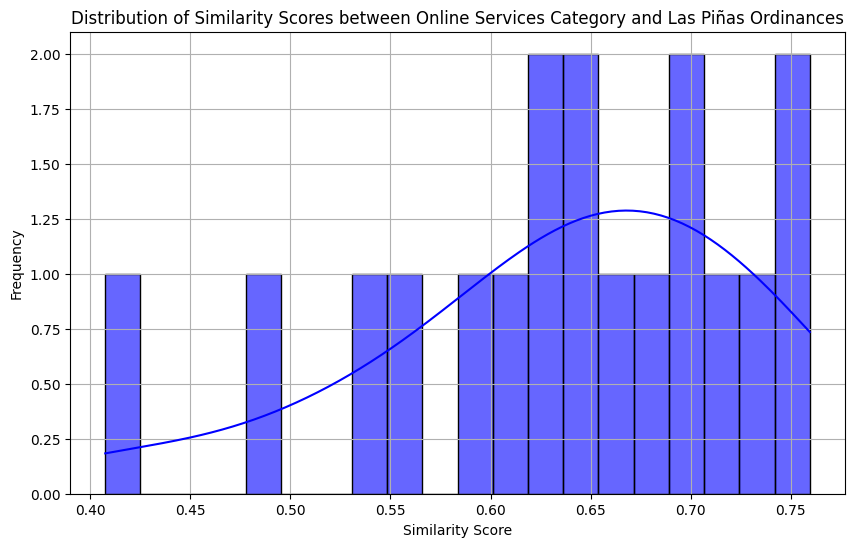

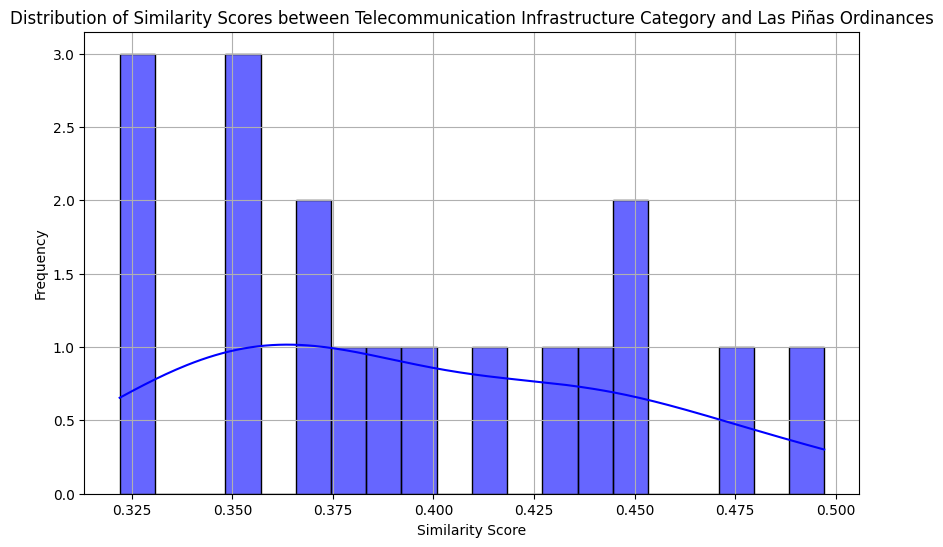

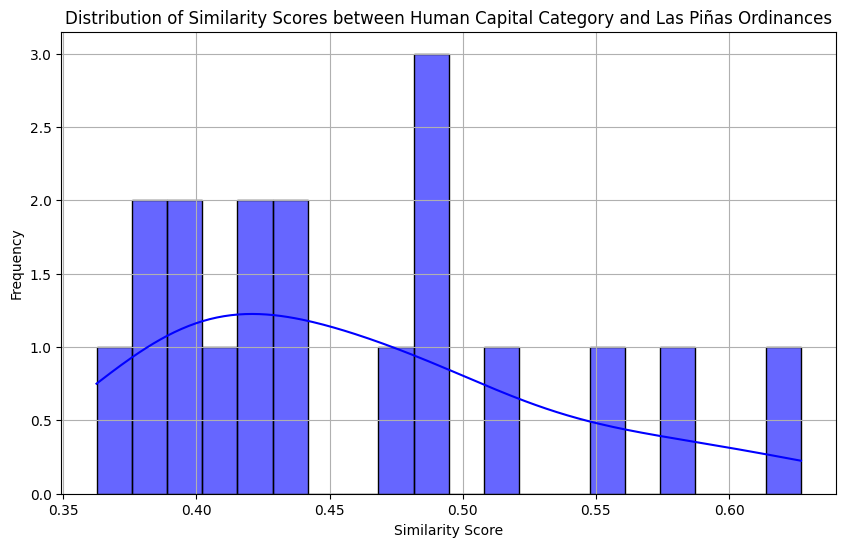

In [ ]:
# Copy of the processed text data for Las Piñas
preprocessed_text_data_las_pinas = copy.deepcopy(processsed_text_data)

# Filter terms based on TF-IDF threshold
las_pinas_filtered_terms = filter_terms_by_tfidf(preprocessed_text_data_las_pinas, text_data_tfidf, text_data_terms, threshold)
las_pinas_filtered_terms = [sub_list for sub_list in las_pinas_filtered_terms if sub_list]

# For online services:
las_pinas_similarities = compute_similarity(cat_filtered_terms[0], las_pinas_filtered_terms[3003:3021], google_model)

# Plotting with matplotlib
plt.figure(figsize=(10, 6))
sns.histplot(las_pinas_similarities, bins=20, kde=True, color='blue', edgecolor='black', alpha=0.6)
# Plotting with matplotlib
plt.title("Distribution of Similarity Scores between Online Services Category and Las Piñas Ordinances")
# Plotting with matplotlib
plt.xlabel("Similarity Score")
# Plotting with matplotlib
plt.ylabel("Frequency")
# Plotting with matplotlib
plt.grid(True)
# Plotting with matplotlib
plt.show()

# For telecommunication infrastructure:
las_pinas_similarities1 = compute_similarity(cat_filtered_terms[1], las_pinas_filtered_terms[3003:3021], google_model)
# Plotting with matplotlib
plt.figure(figsize=(10, 6))
sns.histplot(las_pinas_similarities1, bins=20, kde=True, color='blue', edgecolor='black', alpha=0.6)
# Plotting with matplotlib
plt.title("Distribution of Similarity Scores between Telecommunication Infrastructure Category and Las Piñas Ordinances")
# Plotting with matplotlib
plt.xlabel("Similarity Score")
# Plotting with matplotlib
plt.ylabel("Frequency")
# Plotting with matplotlib
plt.grid(True)
# Plotting with matplotlib
plt.show()

# For human capital:
las_pinas_similarities2 = compute_similarity(cat_filtered_terms[2], las_pinas_filtered_terms[3003:3021], google_model)
# Plotting with matplotlib
plt.figure(figsize=(10, 6))
sns.histplot(las_pinas_similarities2, bins=20, kde=True, color='blue', edgecolor='black', alpha=0.6)
# Plotting with matplotlib
plt.title("Distribution of Similarity Scores between Human Capital Category and Las Piñas Ordinances")
# Plotting with matplotlib
plt.xlabel("Similarity Score")
# Plotting with matplotlib
plt.ylabel("Frequency")
# Plotting with matplotlib
plt.grid(True)
# Plotting with matplotlib
plt.show()

**Paranaque**

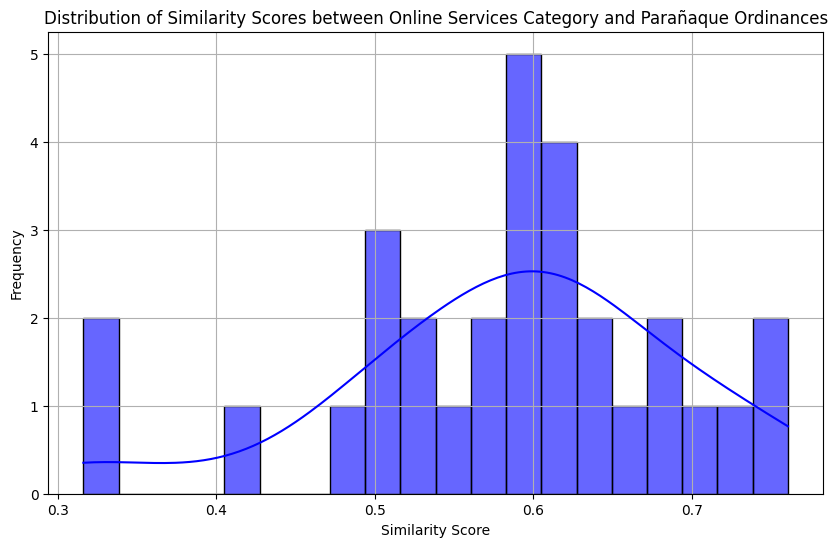

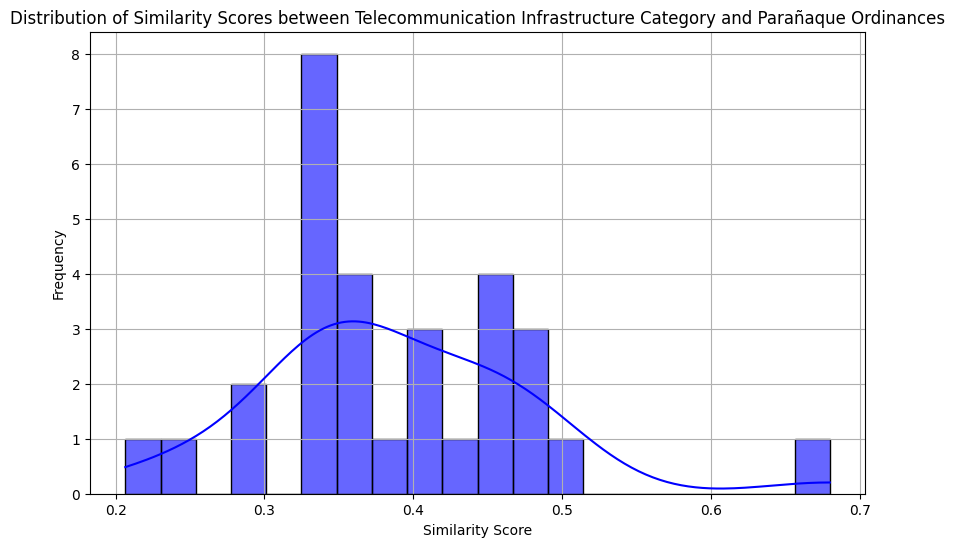

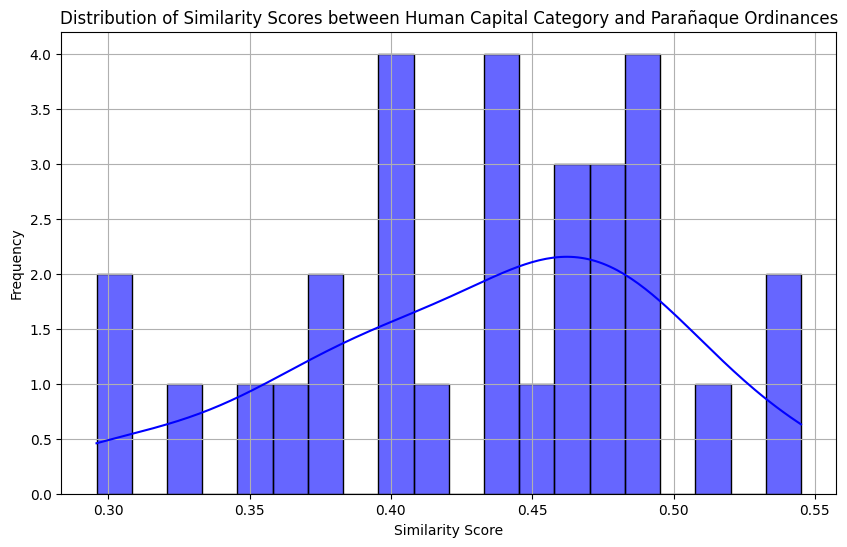

In [ ]:
# Copy of the processed text data for Parañaque
preprocessed_text_data_paranaque = copy.deepcopy(processsed_text_data)

# Filter terms based on TF-IDF threshold
paranaque_filtered_terms = filter_terms_by_tfidf(preprocessed_text_data_paranaque, text_data_tfidf, text_data_terms, threshold)
paranaque_filtered_terms = [sub_list for sub_list in paranaque_filtered_terms if sub_list]

# For online services:
paranaque_similarities = compute_similarity(cat_filtered_terms[0], paranaque_filtered_terms[3022:3052], google_model)

# Plotting with matplotlib
plt.figure(figsize=(10, 6))
sns.histplot(paranaque_similarities, bins=20, kde=True, color='blue', edgecolor='black', alpha=0.6)
# Plotting with matplotlib
plt.title("Distribution of Similarity Scores between Online Services Category and Parañaque Ordinances")
# Plotting with matplotlib
plt.xlabel("Similarity Score")
# Plotting with matplotlib
plt.ylabel("Frequency")
# Plotting with matplotlib
plt.grid(True)
# Plotting with matplotlib
plt.show()

# For telecommunication infrastructure:
paranaque_similarities1 = compute_similarity(cat_filtered_terms[1], paranaque_filtered_terms[3022:3052], google_model)
# Plotting with matplotlib
plt.figure(figsize=(10, 6))
sns.histplot(paranaque_similarities1, bins=20, kde=True, color='blue', edgecolor='black', alpha=0.6)
# Plotting with matplotlib
plt.title("Distribution of Similarity Scores between Telecommunication Infrastructure Category and Parañaque Ordinances")
# Plotting with matplotlib
plt.xlabel("Similarity Score")
# Plotting with matplotlib
plt.ylabel("Frequency")
# Plotting with matplotlib
plt.grid(True)
# Plotting with matplotlib
plt.show()

# For human capital:
paranaque_similarities2 = compute_similarity(cat_filtered_terms[2], paranaque_filtered_terms[3022:3052], google_model)
# Plotting with matplotlib
plt.figure(figsize=(10, 6))
sns.histplot(paranaque_similarities2, bins=20, kde=True, color='blue', edgecolor='black', alpha=0.6)
# Plotting with matplotlib
plt.title("Distribution of Similarity Scores between Human Capital Category and Parañaque Ordinances")
# Plotting with matplotlib
plt.xlabel("Similarity Score")
# Plotting with matplotlib
plt.ylabel("Frequency")
# Plotting with matplotlib
plt.grid(True)
# Plotting with matplotlib
plt.show()

**Cagayan de Oro**

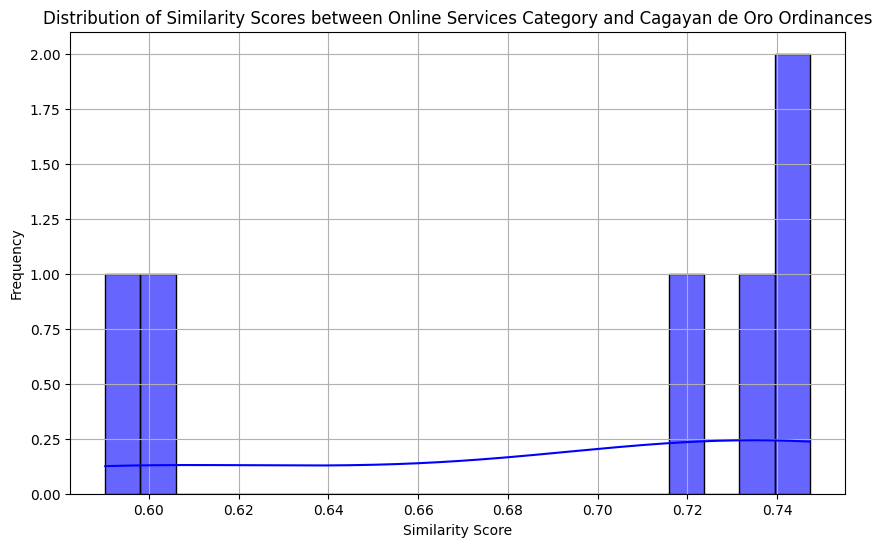

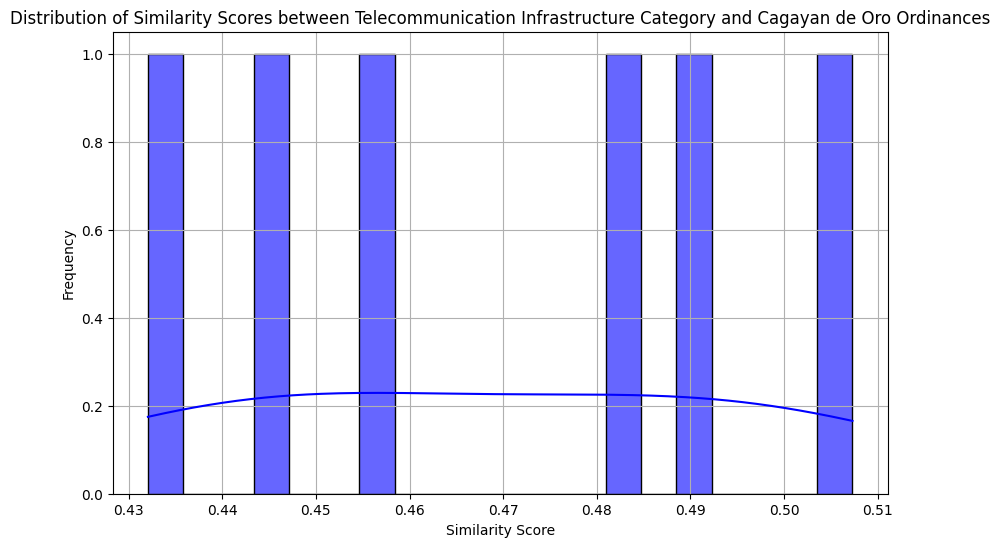

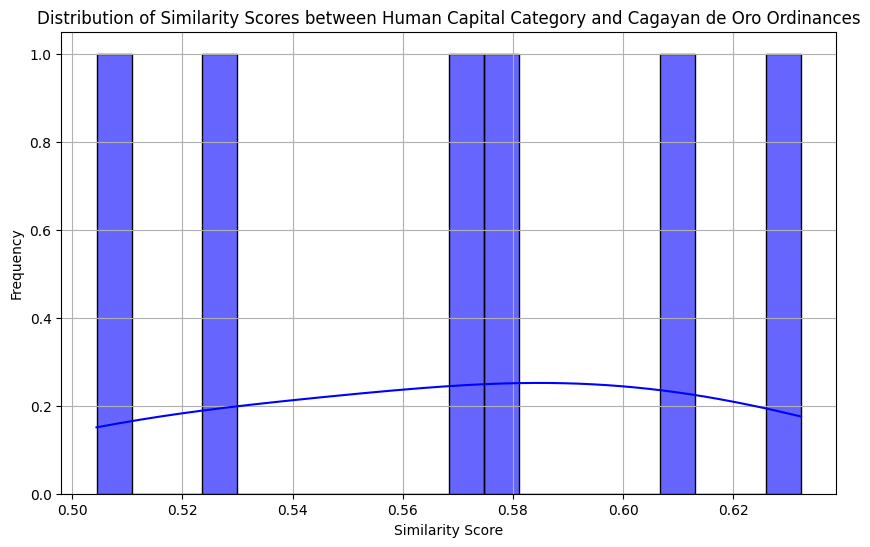

In [ ]:
# Copy of the processed text data for Cagayan de Oro
preprocessed_text_data_cagayan_de_oro = copy.deepcopy(processsed_text_data)

# Filter terms based on TF-IDF threshold
cagayan_de_oro_filtered_terms = filter_terms_by_tfidf(preprocessed_text_data_cagayan_de_oro, text_data_tfidf, text_data_terms, threshold)
cagayan_de_oro_filtered_terms = [sub_list for sub_list in cagayan_de_oro_filtered_terms if sub_list]

# For online services:
cagayan_de_oro_similarities = compute_similarity(cat_filtered_terms[0], cagayan_de_oro_filtered_terms[3053:3059], google_model)

# Plotting with matplotlib
plt.figure(figsize=(10, 6))
sns.histplot(cagayan_de_oro_similarities, bins=20, kde=True, color='blue', edgecolor='black', alpha=0.6)
# Plotting with matplotlib
plt.title("Distribution of Similarity Scores between Online Services Category and Cagayan de Oro Ordinances")
# Plotting with matplotlib
plt.xlabel("Similarity Score")
# Plotting with matplotlib
plt.ylabel("Frequency")
# Plotting with matplotlib
plt.grid(True)
# Plotting with matplotlib
plt.show()

# For telecommunication infrastructure:
cagayan_de_oro_similarities1 = compute_similarity(cat_filtered_terms[1], cagayan_de_oro_filtered_terms[3053:3059], google_model)
# Plotting with matplotlib
plt.figure(figsize=(10, 6))
sns.histplot(cagayan_de_oro_similarities1, bins=20, kde=True, color='blue', edgecolor='black', alpha=0.6)
# Plotting with matplotlib
plt.title("Distribution of Similarity Scores between Telecommunication Infrastructure Category and Cagayan de Oro Ordinances")
# Plotting with matplotlib
plt.xlabel("Similarity Score")
# Plotting with matplotlib
plt.ylabel("Frequency")
# Plotting with matplotlib
plt.grid(True)
# Plotting with matplotlib
plt.show()

# For human capital:
cagayan_de_oro_similarities2 = compute_similarity(cat_filtered_terms[2], cagayan_de_oro_filtered_terms[3053:3059], google_model)
# Plotting with matplotlib
plt.figure(figsize=(10, 6))
sns.histplot(cagayan_de_oro_similarities2, bins=20, kde=True, color='blue', edgecolor='black', alpha=0.6)
# Plotting with matplotlib
plt.title("Distribution of Similarity Scores between Human Capital Category and Cagayan de Oro Ordinances")
# Plotting with matplotlib
plt.xlabel("Similarity Score")
# Plotting with matplotlib
plt.ylabel("Frequency")
# Plotting with matplotlib
plt.grid(True)
# Plotting with matplotlib
plt.show()

**Caloocan**

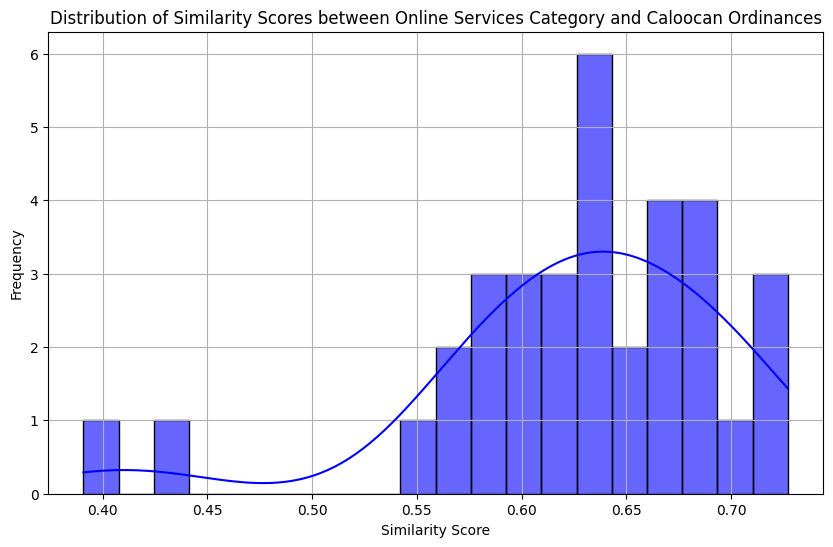

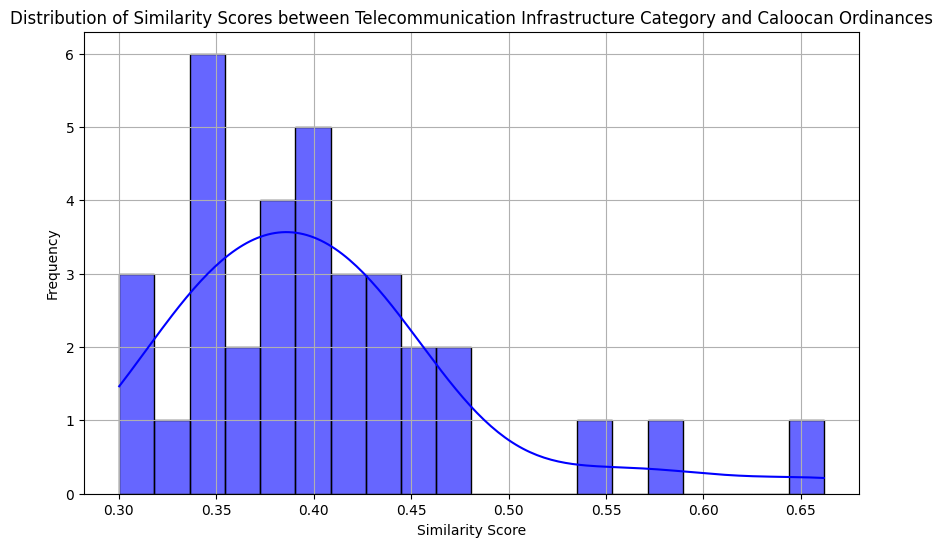

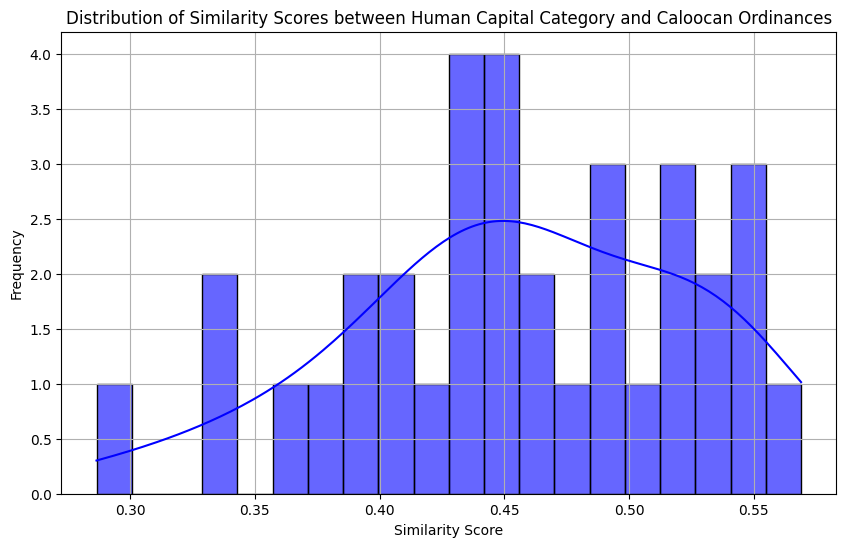

In [ ]:
# Copy of the processed text data for Caloocan
preprocessed_text_data_caloocan = copy.deepcopy(processsed_text_data)

# Filter terms based on TF-IDF threshold
caloocan_filtered_terms = filter_terms_by_tfidf(preprocessed_text_data_caloocan, text_data_tfidf, text_data_terms, threshold)
caloocan_filtered_terms = [sub_list for sub_list in caloocan_filtered_terms if sub_list]

# For online services:
caloocan_similarities = compute_similarity(cat_filtered_terms[0], caloocan_filtered_terms[3060:3094], google_model)

# Plotting with matplotlib
plt.figure(figsize=(10, 6))
sns.histplot(caloocan_similarities, bins=20, kde=True, color='blue', edgecolor='black', alpha=0.6)
# Plotting with matplotlib
plt.title("Distribution of Similarity Scores between Online Services Category and Caloocan Ordinances")
# Plotting with matplotlib
plt.xlabel("Similarity Score")
# Plotting with matplotlib
plt.ylabel("Frequency")
# Plotting with matplotlib
plt.grid(True)
# Plotting with matplotlib
plt.show()

# For telecommunication infrastructure:
caloocan_similarities1 = compute_similarity(cat_filtered_terms[1], caloocan_filtered_terms[3060:3094], google_model)
# Plotting with matplotlib
plt.figure(figsize=(10, 6))
sns.histplot(caloocan_similarities1, bins=20, kde=True, color='blue', edgecolor='black', alpha=0.6)
# Plotting with matplotlib
plt.title("Distribution of Similarity Scores between Telecommunication Infrastructure Category and Caloocan Ordinances")
# Plotting with matplotlib
plt.xlabel("Similarity Score")
# Plotting with matplotlib
plt.ylabel("Frequency")
# Plotting with matplotlib
plt.grid(True)
# Plotting with matplotlib
plt.show()

# For human capital:
caloocan_similarities2 = compute_similarity(cat_filtered_terms[2], caloocan_filtered_terms[3060:3094], google_model)
# Plotting with matplotlib
plt.figure(figsize=(10, 6))
sns.histplot(caloocan_similarities2, bins=20, kde=True, color='blue', edgecolor='black', alpha=0.6)
# Plotting with matplotlib
plt.title("Distribution of Similarity Scores between Human Capital Category and Caloocan Ordinances")
# Plotting with matplotlib
plt.xlabel("Similarity Score")
# Plotting with matplotlib
plt.ylabel("Frequency")
# Plotting with matplotlib
plt.grid(True)
# Plotting with matplotlib
plt.show()

**Iligan**

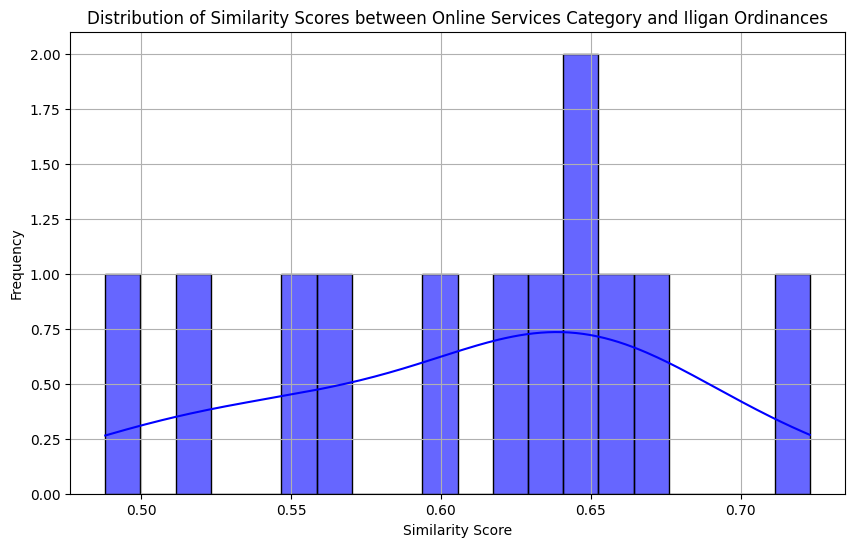

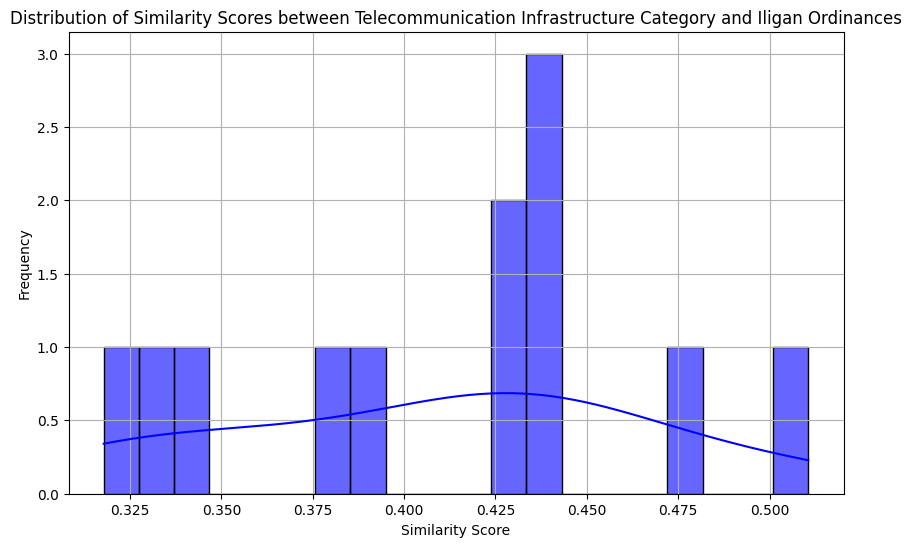

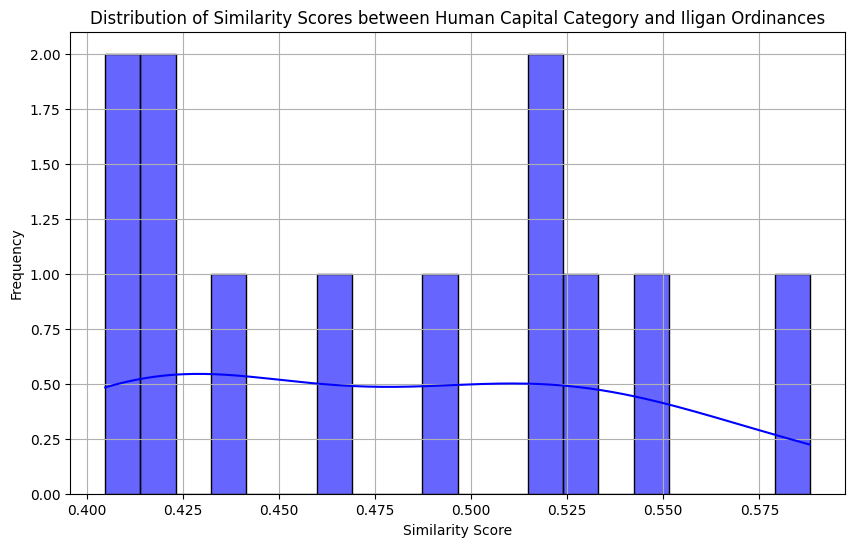

In [ ]:
# Copy of the processed text data for Iligan
preprocessed_text_data_iligan = copy.deepcopy(processsed_text_data)

# Filter terms based on TF-IDF threshold
iligan_filtered_terms = filter_terms_by_tfidf(preprocessed_text_data_iligan, text_data_tfidf, text_data_terms, threshold)
iligan_filtered_terms = [sub_list for sub_list in iligan_filtered_terms if sub_list]

# For online services:
iligan_similarities = compute_similarity(cat_filtered_terms[0], iligan_filtered_terms[3095:3107], google_model)

# Plotting with matplotlib
plt.figure(figsize=(10, 6))
sns.histplot(iligan_similarities, bins=20, kde=True, color='blue', edgecolor='black', alpha=0.6)
# Plotting with matplotlib
plt.title("Distribution of Similarity Scores between Online Services Category and Iligan Ordinances")
# Plotting with matplotlib
plt.xlabel("Similarity Score")
# Plotting with matplotlib
plt.ylabel("Frequency")
# Plotting with matplotlib
plt.grid(True)
# Plotting with matplotlib
plt.show()

# For telecommunication infrastructure:
iligan_similarities1 = compute_similarity(cat_filtered_terms[1], iligan_filtered_terms[3095:3107], google_model)
# Plotting with matplotlib
plt.figure(figsize=(10, 6))
sns.histplot(iligan_similarities1, bins=20, kde=True, color='blue', edgecolor='black', alpha=0.6)
# Plotting with matplotlib
plt.title("Distribution of Similarity Scores between Telecommunication Infrastructure Category and Iligan Ordinances")
# Plotting with matplotlib
plt.xlabel("Similarity Score")
# Plotting with matplotlib
plt.ylabel("Frequency")
# Plotting with matplotlib
plt.grid(True)
# Plotting with matplotlib
plt.show()

# For human capital:
iligan_similarities2 = compute_similarity(cat_filtered_terms[2], iligan_filtered_terms[3095:3107], google_model)
# Plotting with matplotlib
plt.figure(figsize=(10, 6))
sns.histplot(iligan_similarities2, bins=20, kde=True, color='blue', edgecolor='black', alpha=0.6)
# Plotting with matplotlib
plt.title("Distribution of Similarity Scores between Human Capital Category and Iligan Ordinances")
# Plotting with matplotlib
plt.xlabel("Similarity Score")
# Plotting with matplotlib
plt.ylabel("Frequency")
# Plotting with matplotlib
plt.grid(True)
# Plotting with matplotlib
plt.show()

**Pasig**

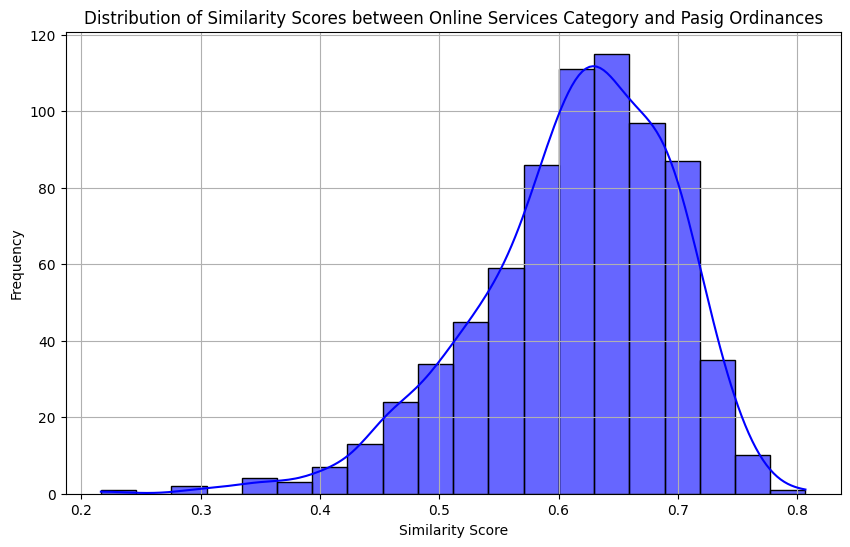

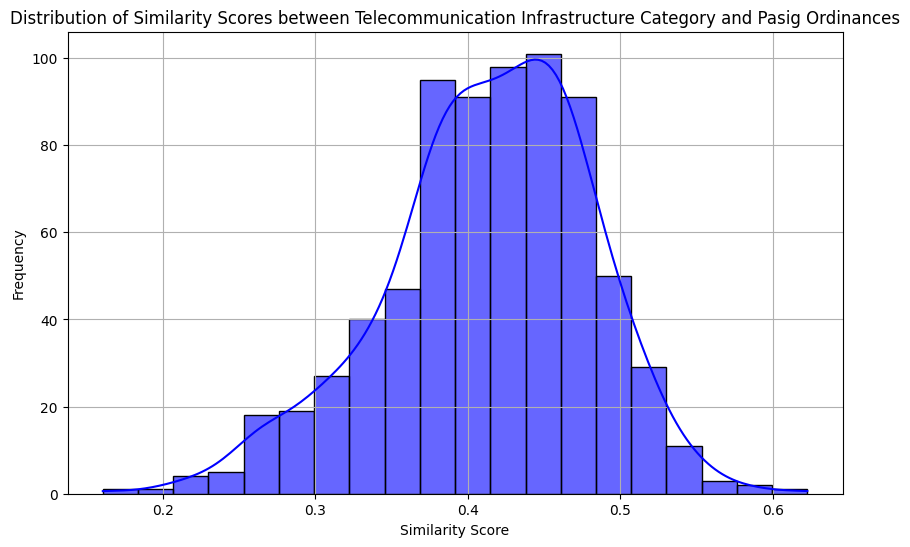

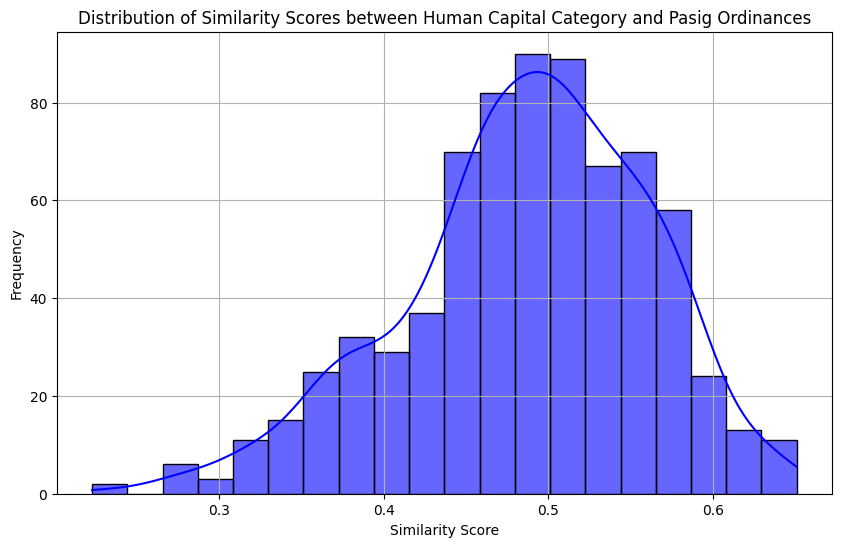

In [ ]:
# Copy of the processed text data for Pasig
preprocessed_text_data_pasig = copy.deepcopy(processsed_text_data)

# Filter terms based on TF-IDF threshold
pasig_filtered_terms = filter_terms_by_tfidf(preprocessed_text_data_pasig, text_data_tfidf, text_data_terms, threshold)
pasig_filtered_terms = [sub_list for sub_list in pasig_filtered_terms if sub_list]

# For online services:
pasig_similarities = compute_similarity(cat_filtered_terms[0], pasig_filtered_terms[3108:3842], google_model)

# Plotting with matplotlib
plt.figure(figsize=(10, 6))
sns.histplot(pasig_similarities, bins=20, kde=True, color='blue', edgecolor='black', alpha=0.6)
# Plotting with matplotlib
plt.title("Distribution of Similarity Scores between Online Services Category and Pasig Ordinances")
# Plotting with matplotlib
plt.xlabel("Similarity Score")
# Plotting with matplotlib
plt.ylabel("Frequency")
# Plotting with matplotlib
plt.grid(True)
# Plotting with matplotlib
plt.show()

# For telecommunication infrastructure:
pasig_similarities1 = compute_similarity(cat_filtered_terms[1], pasig_filtered_terms[3108:3842], google_model)
# Plotting with matplotlib
plt.figure(figsize=(10, 6))
sns.histplot(pasig_similarities1, bins=20, kde=True, color='blue', edgecolor='black', alpha=0.6)
# Plotting with matplotlib
plt.title("Distribution of Similarity Scores between Telecommunication Infrastructure Category and Pasig Ordinances")
# Plotting with matplotlib
plt.xlabel("Similarity Score")
# Plotting with matplotlib
plt.ylabel("Frequency")
# Plotting with matplotlib
plt.grid(True)
# Plotting with matplotlib
plt.show()

# For human capital:
pasig_similarities2 = compute_similarity(cat_filtered_terms[2], pasig_filtered_terms[3108:3842], google_model)
# Plotting with matplotlib
plt.figure(figsize=(10, 6))
sns.histplot(pasig_similarities2, bins=20, kde=True, color='blue', edgecolor='black', alpha=0.6)
# Plotting with matplotlib
plt.title("Distribution of Similarity Scores between Human Capital Category and Pasig Ordinances")
# Plotting with matplotlib
plt.xlabel("Similarity Score")
# Plotting with matplotlib
plt.ylabel("Frequency")
# Plotting with matplotlib
plt.grid(True)
# Plotting with matplotlib
plt.show()

**Makati**

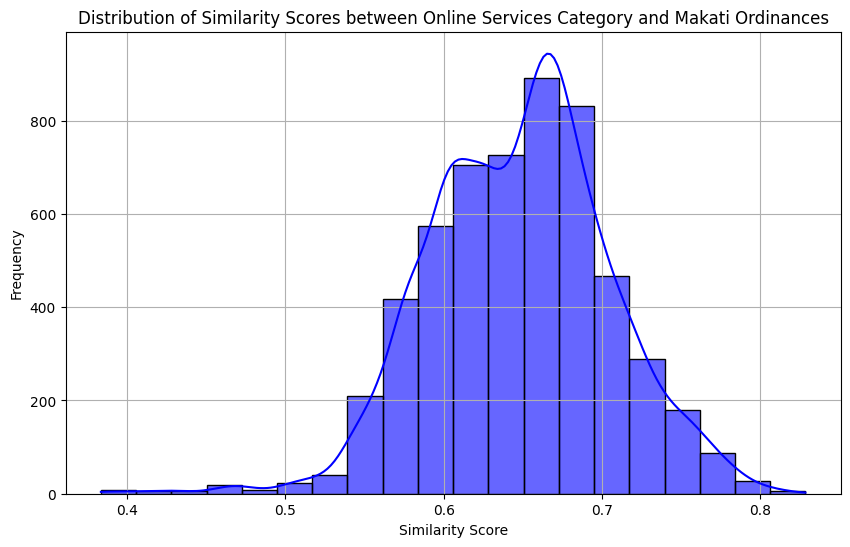

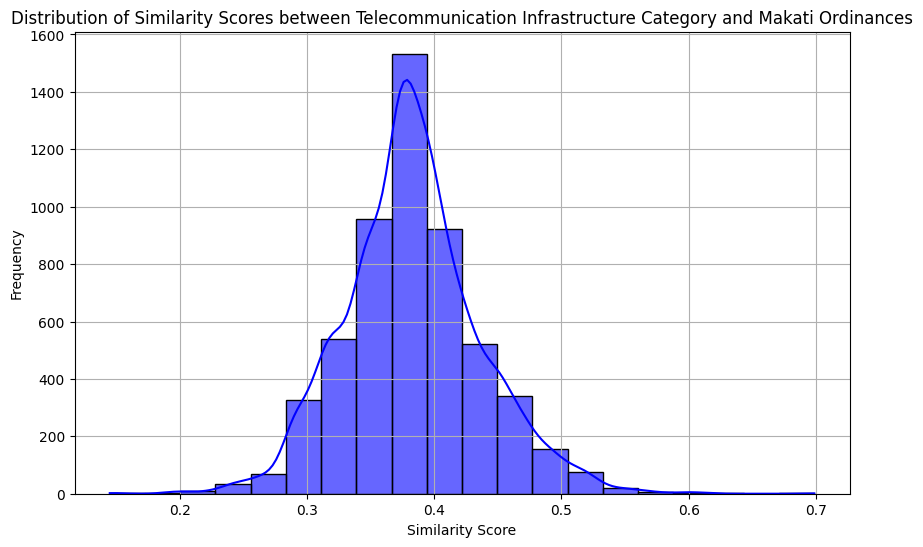

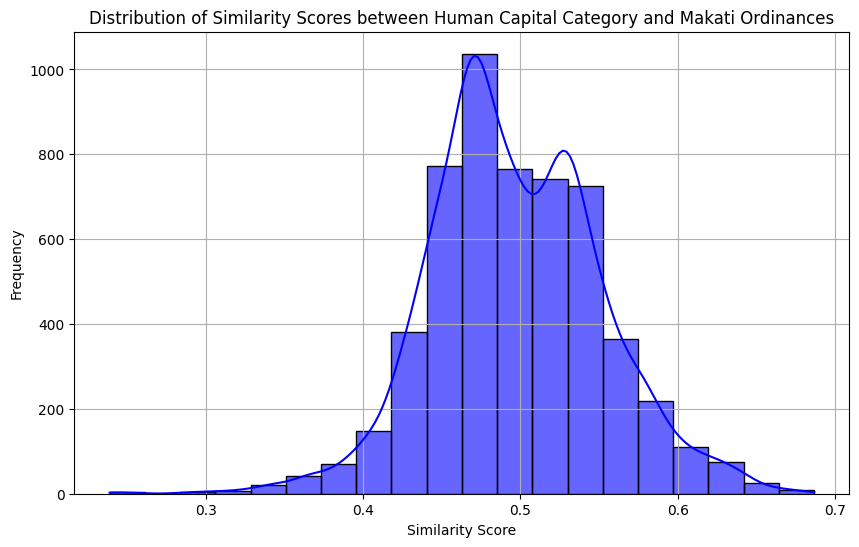

In [ ]:
# Copy of the processed text data for Makati
preprocessed_text_data_makati = copy.deepcopy(processsed_text_data)

# Filter terms based on TF-IDF threshold
makati_filtered_terms = filter_terms_by_tfidf(preprocessed_text_data_makati, text_data_tfidf, text_data_terms, threshold)
makati_filtered_terms = [sub_list for sub_list in makati_filtered_terms if sub_list]

# For online services:
makati_similarities = compute_similarity(cat_filtered_terms[0], makati_filtered_terms[3843:9363], google_model)

# Plotting with matplotlib
plt.figure(figsize=(10, 6))
sns.histplot(makati_similarities, bins=20, kde=True, color='blue', edgecolor='black', alpha=0.6)
# Plotting with matplotlib
plt.title("Distribution of Similarity Scores between Online Services Category and Makati Ordinances")
# Plotting with matplotlib
plt.xlabel("Similarity Score")
# Plotting with matplotlib
plt.ylabel("Frequency")
# Plotting with matplotlib
plt.grid(True)
# Plotting with matplotlib
plt.show()

# For telecommunication infrastructure:
makati_similarities1 = compute_similarity(cat_filtered_terms[1], makati_filtered_terms[3843:9363], google_model)
# Plotting with matplotlib
plt.figure(figsize=(10, 6))
sns.histplot(makati_similarities1, bins=20, kde=True, color='blue', edgecolor='black', alpha=0.6)
# Plotting with matplotlib
plt.title("Distribution of Similarity Scores between Telecommunication Infrastructure Category and Makati Ordinances")
# Plotting with matplotlib
plt.xlabel("Similarity Score")
# Plotting with matplotlib
plt.ylabel("Frequency")
# Plotting with matplotlib
plt.grid(True)
# Plotting with matplotlib
plt.show()

# For human capital:
makati_similarities2 = compute_similarity(cat_filtered_terms[2], makati_filtered_terms[3843:9363], google_model)
# Plotting with matplotlib
plt.figure(figsize=(10, 6))
sns.histplot(makati_similarities2, bins=20, kde=True, color='blue', edgecolor='black', alpha=0.6)
# Plotting with matplotlib
plt.title("Distribution of Similarity Scores between Human Capital Category and Makati Ordinances")
# Plotting with matplotlib
plt.xlabel("Similarity Score")
# Plotting with matplotlib
plt.ylabel("Frequency")
# Plotting with matplotlib
plt.grid(True)
# Plotting with matplotlib
plt.show()

**Quezon**

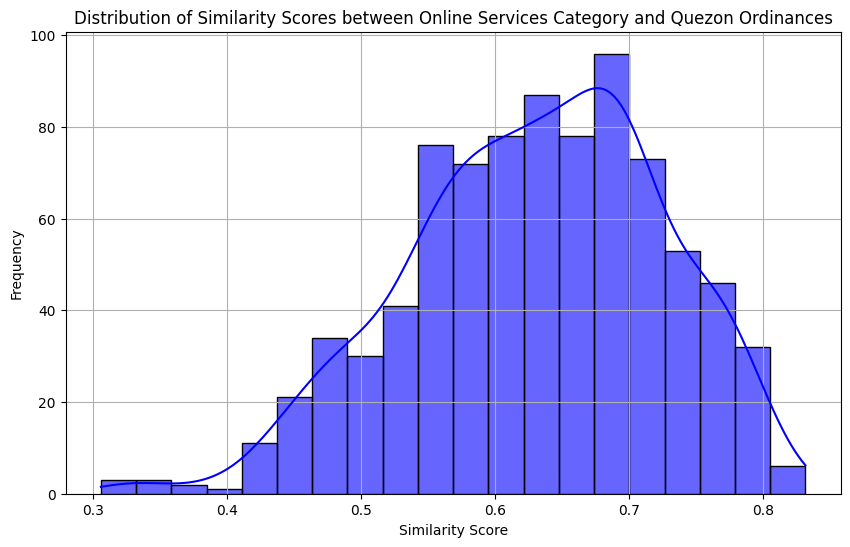

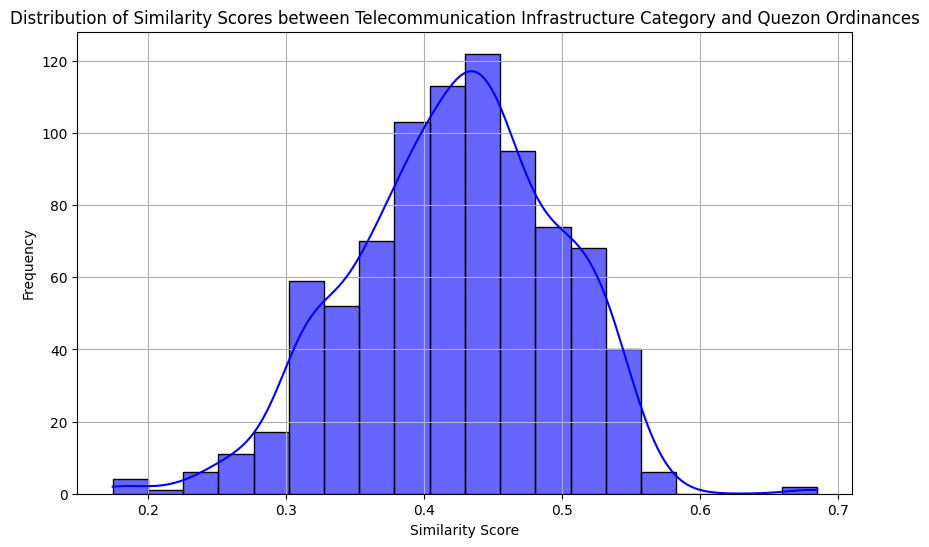

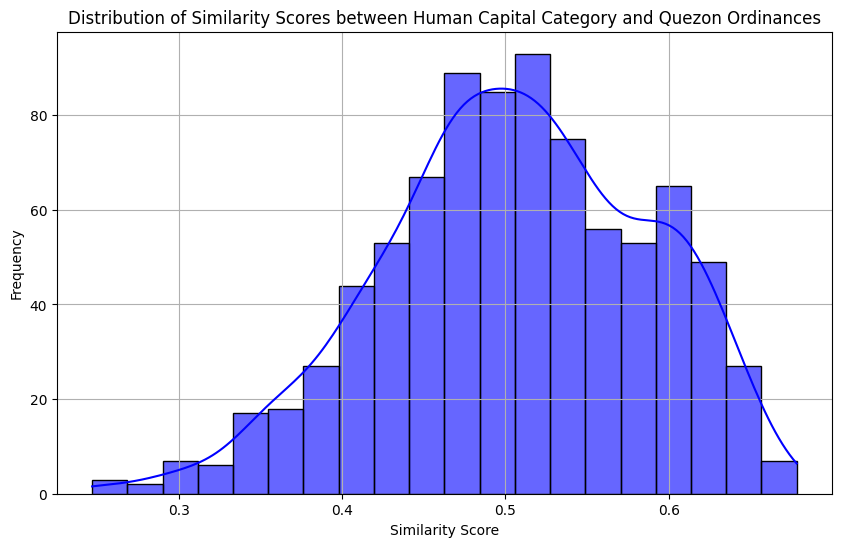

In [ ]:
# Copy of the processed text data for Quezon
preprocessed_text_data_quezon = copy.deepcopy(processsed_text_data)

# Filter terms based on TF-IDF threshold
quezon_filtered_terms = filter_terms_by_tfidf(preprocessed_text_data_quezon, text_data_tfidf, text_data_terms, threshold)
quezon_filtered_terms = [sub_list for sub_list in quezon_filtered_terms if sub_list]

# For online services:
quezon_similarities = compute_similarity(cat_filtered_terms[0], quezon_filtered_terms[9364:10208], google_model)

# Plotting with matplotlib
plt.figure(figsize=(10, 6))
sns.histplot(quezon_similarities, bins=20, kde=True, color='blue', edgecolor='black', alpha=0.6)
# Plotting with matplotlib
plt.title("Distribution of Similarity Scores between Online Services Category and Quezon Ordinances")
# Plotting with matplotlib
plt.xlabel("Similarity Score")
# Plotting with matplotlib
plt.ylabel("Frequency")
# Plotting with matplotlib
plt.grid(True)
# Plotting with matplotlib
plt.show()

# For telecommunication infrastructure:
quezon_similarities1 = compute_similarity(cat_filtered_terms[1], quezon_filtered_terms[9364:10208], google_model)
# Plotting with matplotlib
plt.figure(figsize=(10, 6))
sns.histplot(quezon_similarities1, bins=20, kde=True, color='blue', edgecolor='black', alpha=0.6)
# Plotting with matplotlib
plt.title("Distribution of Similarity Scores between Telecommunication Infrastructure Category and Quezon Ordinances")
# Plotting with matplotlib
plt.xlabel("Similarity Score")
# Plotting with matplotlib
plt.ylabel("Frequency")
# Plotting with matplotlib
plt.grid(True)
# Plotting with matplotlib
plt.show()

# For human capital:
quezon_similarities2 = compute_similarity(cat_filtered_terms[2], quezon_filtered_terms[9364:10208], google_model)
# Plotting with matplotlib
plt.figure(figsize=(10, 6))
sns.histplot(quezon_similarities2, bins=20, kde=True, color='blue', edgecolor='black', alpha=0.6)
# Plotting with matplotlib
plt.title("Distribution of Similarity Scores between Human Capital Category and Quezon Ordinances")
# Plotting with matplotlib
plt.xlabel("Similarity Score")
# Plotting with matplotlib
plt.ylabel("Frequency")
# Plotting with matplotlib
plt.grid(True)
# Plotting with matplotlib
plt.show()